In [1]:
# %pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')
import re
from math import radians, sin, cos, sqrt, atan2

# 设置中文字体显示（如果图表需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 1.读取Excel文件
try:
    # 读取租房数据  
    rent_price_df = pd.read_excel(r"D:\desktop\ruc_Class25Q2_train_price.xlsx")
    print("购房数据读取成功！")
    print(f"购房数据形状: {rent_price_df.shape}")
    
except FileNotFoundError as e:
    print(f"文件未找到: {e}")
except Exception as e:
    print(f"读取文件时出错: {e}")

# 查看数据的基本信息
print("\n=== 购房数据基本信息 ===")
print(f"行数: {rent_price_df.shape[0]}, 列数: {rent_price_df.shape[1]}")
print(rent_price_df.info())

# 查看前几行数据
print("\n=== 购房数据前3行 ===")
print(rent_price_df.head(3))

# 检查列名
print("\n=== 购房数据列名 ===")
print(rent_price_df.columns.tolist())

购房数据读取成功！
购房数据形状: (103871, 55)

=== 购房数据基本信息 ===
行数: 103871, 列数: 55
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103871 entries, 0 to 103870
Data columns (total 55 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   城市         103871 non-null  int64         
 1   区域         103871 non-null  int64         
 2   板块         103871 non-null  int64         
 3   环线         40419 non-null   object        
 4   Price      103871 non-null  float64       
 5   房屋户型       103291 non-null  object        
 6   所在楼层       103871 non-null  object        
 7   建筑面积       103871 non-null  object        
 8   套内面积       35984 non-null   object        
 9   房屋朝向       103870 non-null  object        
 10  建筑结构       103291 non-null  object        
 11  装修情况       103291 non-null  object        
 12  梯户比例       101252 non-null  object        
 13  配备电梯       91520 non-null   object        
 14  别墅类型       1443 non-null    object        
 15  

价格取对数完成!

价格变量统计信息对比:
原始价格 (price) 统计:
  平均值: 2262366.07
  标准差: 2532925.40
  最小值: 74553.30
  最大值: 56226431.30

对数价格 (lnPrice) 统计:
  平均值: 14.26
  标准差: 0.83
  最小值: 11.22
  最大值: 17.84

数据质量检查:
  lnPrice缺失值数量: 0
  lnPrice无限值数量: 0


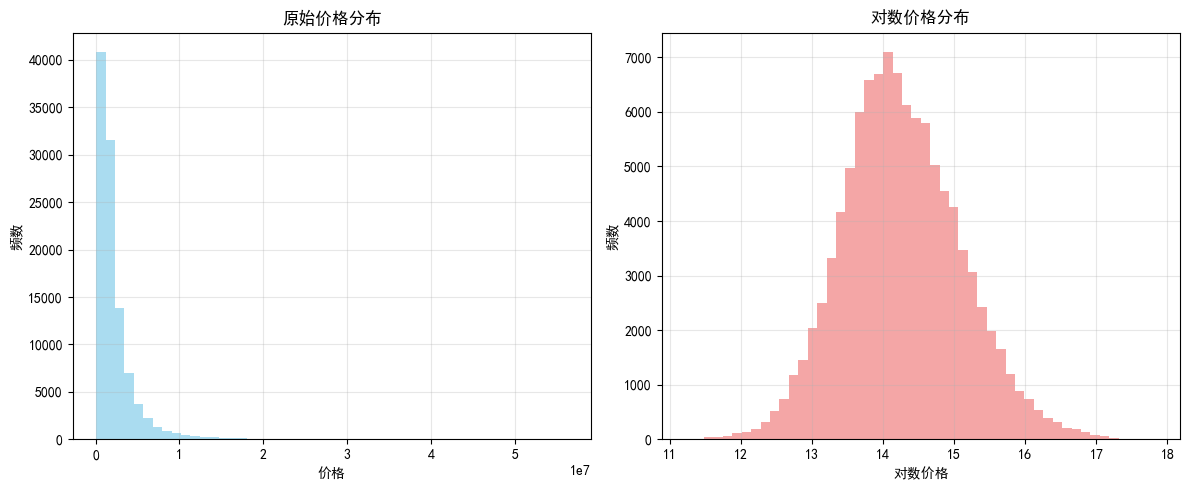


价格取对数示例:
          Price    lnPrice
0  6.194049e+06  15.639100
1  4.354153e+06  15.286641
2  3.321992e+06  15.016075
3  7.895656e+06  15.881823
4  1.902960e+06  14.458921
5  1.645915e+07  16.616392
6  3.631467e+06  15.105147
7  2.098983e+05  12.254379
8  1.189620e+07  16.291730
9  1.093772e+07  16.207728


In [3]:
# 2 变量处理

# 2.1 价格变量（因变量）

rent_price_df['lnPrice'] = np.log(rent_price_df['Price'])
print("价格取对数完成!")

# 查看处理前后的统计信息对比
print("\n价格变量统计信息对比:")
print("原始价格 (price) 统计:")
print(f"  平均值: {rent_price_df['Price'].mean():.2f}")
print(f"  标准差: {rent_price_df['Price'].std():.2f}")
print(f"  最小值: {rent_price_df['Price'].min():.2f}")
print(f"  最大值: {rent_price_df['Price'].max():.2f}")

print("\n对数价格 (lnPrice) 统计:")
print(f"  平均值: {rent_price_df['lnPrice'].mean():.2f}")
print(f"  标准差: {rent_price_df['lnPrice'].std():.2f}")
print(f"  最小值: {rent_price_df['lnPrice'].min():.2f}")
print(f"  最大值: {rent_price_df['lnPrice'].max():.2f}")

# 检查是否有无限值或缺失值
print(f"\n数据质量检查:")
print(f"  lnPrice缺失值数量: {rent_price_df['lnPrice'].isnull().sum()}")
print(f"  lnPrice无限值数量: {np.isinf(rent_price_df['lnPrice']).sum()}")

# 如果有价格小于等于0的情况，对数转换会产生问题
negative_or_zero_prices = rent_price_df[rent_price_df['Price'] <= 0]
if len(negative_or_zero_prices) > 0:
    print(f"\n警告: 发现 {len(negative_or_zero_prices)} 个非正价格，这些值的对数将产生问题")
    print("非正价格示例:")
    print(negative_or_zero_prices[['Price']].head())

# 可视化价格和对数价格的分布
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 原始价格分布
ax1.hist(rent_price_df['Price'].dropna(), bins=50, alpha=0.7, color='skyblue')
ax1.set_xlabel('价格')
ax1.set_ylabel('频数')
ax1.set_title('原始价格分布')
ax1.grid(True, alpha=0.3)

# 对数价格分布
ax2.hist(rent_price_df['lnPrice'].dropna(), bins=50, alpha=0.7, color='lightcoral')
ax2.set_xlabel('对数价格')
ax2.set_ylabel('频数')
ax2.set_title('对数价格分布')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 查看一些具体示例
print("\n价格取对数示例:")
sample_data = rent_price_df[['Price', 'lnPrice']].head(10)
print(sample_data)

In [4]:
# 2.2 装修变量
# 2.2.1 分布检查
print("装修情况分布:")
print(rent_price_df['装修情况'].value_counts())

# 2.2.2 缺失值检查
print(f"\n装修情况缺失值数量: {rent_price_df['装修情况'].isna().sum()}")

# 2.2.3 创建装修情况哑变量
# 删除已存在的装修哑变量列
decoration_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('decoration_')]
rent_price_df = rent_price_df.drop(columns=decoration_columns_to_drop)

# 定义所有可能的装修类型
all_decoration_types = ['精装', '简装', '毛坯', '其他']

# 创建哑变量
decoration_dummies = pd.get_dummies(rent_price_df['装修情况'], prefix='decoration')

# 确保包含所有装修类型（即使某些类型没有数据）
for deco_type in all_decoration_types:
    col_name = f"decoration_{deco_type}"
    if col_name not in decoration_dummies.columns:
        decoration_dummies[col_name] = 0

# 按正确的顺序排列列
decoration_dummies = decoration_dummies.reindex(columns=[f"decoration_{deco_type}" for deco_type in all_decoration_types])

# 将布尔值转换为整数 (True/False -> 1/0)
decoration_dummies = decoration_dummies.astype(int)

# 将原始数据中的缺失值反映到哑变量中
if rent_price_df['装修情况'].isna().any():
    na_mask = rent_price_df['装修情况'].isna()
    for col in decoration_dummies.columns:
        decoration_dummies.loc[na_mask, col] = np.nan

# 将哑变量合并到原数据框
rent_price_df = pd.concat([rent_price_df, decoration_dummies], axis=1)

print(f"\n已创建的装修情况哑变量:")
decoration_dummy_columns = [col for col in rent_price_df.columns if col.startswith('decoration_')]
print(decoration_dummy_columns)

print("\n装修情况哑变量分布:")
for col in decoration_dummy_columns:
    valid_count = rent_price_df[col].notna().sum()
    true_count = (rent_price_df[col] == 1).sum()
    na_count = rent_price_df[col].isna().sum()
    print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

print("装修情况哑变量创建完成（保留缺失值）")

装修情况分布:
装修情况
精装    46585
其他    23820
简装    20522
毛坯    12364
Name: count, dtype: int64

装修情况缺失值数量: 580

已创建的装修情况哑变量:
['decoration_精装', 'decoration_简装', 'decoration_毛坯', 'decoration_其他']

装修情况哑变量分布:
decoration_精装: 46585个为1, 56706个为0, 580个缺失
decoration_简装: 20522个为1, 82769个为0, 580个缺失
decoration_毛坯: 12364个为1, 90927个为0, 580个缺失
decoration_其他: 23820个为1, 79471个为0, 580个缺失
装修情况哑变量创建完成（保留缺失值）


In [5]:
# 2.3 楼层变量
# 2.3.1 分布检查
print("楼层分布:")
print(rent_price_df['所在楼层'].value_counts())

# 2.3.2 缺失值检查
print(f"\n楼层缺失值数量: {rent_price_df['所在楼层'].isna().sum()}")

# 2.3.3 创建楼层变量
# 删除已存在的楼层变量列
floor_columns_to_drop = [col for col in rent_price_df.columns if 
                        col in ['high_dummy', 'middle_dummy', 'low_dummy', 
                               'basement_dummy', 'top_dummy', 'bottom_dummy', 'total_floor']]
rent_price_df = rent_price_df.drop(columns=floor_columns_to_drop)

# 从楼层数据中提取7个变量:
# 1. 高哑变量 (high_dummy)
# 2. 中哑变量 (middle_dummy) 
# 3. 低哑变量 (low_dummy)
# 4. 地下室哑变量 (basement_dummy)
# 5. 顶层哑变量 (top_dummy)
# 6. 底层哑变量 (bottom_dummy)
# 7. 总楼层连续变量 (total_floor)

def extract_floor_features_purchase(df, floor_column='所在楼层'):
    """
    从购房数据楼层信息中提取7个变量
    """
    # 创建新列，初始化为NaN
    df['high_dummy'] = np.nan
    df['middle_dummy'] = np.nan
    df['low_dummy'] = np.nan
    df['basement_dummy'] = np.nan
    df['top_dummy'] = np.nan
    df['bottom_dummy'] = np.nan
    df['total_floor'] = np.nan
    
    # 只对非空楼层进行处理
    valid_mask = df[floor_column].notna()
    
    # 将楼层列转换为字符串类型
    floor_str = df.loc[valid_mask, floor_column].astype(str)
    
    # 初始化有效数据中的哑变量为0
    df.loc[valid_mask, 'high_dummy'] = 0
    df.loc[valid_mask, 'middle_dummy'] = 0
    df.loc[valid_mask, 'low_dummy'] = 0
    df.loc[valid_mask, 'basement_dummy'] = 0
    df.loc[valid_mask, 'top_dummy'] = 0
    df.loc[valid_mask, 'bottom_dummy'] = 0
    
    # 处理地下室情况
    basement_mask = floor_str.str.contains('地下室')
    df.loc[valid_mask & basement_mask, 'basement_dummy'] = 1
    
    # 处理顶层情况
    top_mask = floor_str.str.contains('顶层')
    df.loc[valid_mask & top_mask, 'top_dummy'] = 1
    
    # 处理底层情况
    bottom_mask = floor_str.str.contains('底层')
    df.loc[valid_mask & bottom_mask, 'bottom_dummy'] = 1
    
    # 处理高楼层情况
    high_mask = floor_str.str.contains('高楼层') & ~top_mask
    df.loc[valid_mask & high_mask, 'high_dummy'] = 1
    
    # 处理中楼层情况
    middle_mask = floor_str.str.contains('中楼层')
    df.loc[valid_mask & middle_mask, 'middle_dummy'] = 1
    
    # 处理低楼层情况
    low_mask = floor_str.str.contains('低楼层') & ~bottom_mask
    df.loc[valid_mask & low_mask, 'low_dummy'] = 1
    
    # 提取总楼层数 - 从"共XX层"格式中提取
    # 匹配"共XX层"模式
    total_floor_match = floor_str.str.extract(r'共(\d+)层')
    df.loc[valid_mask, 'total_floor'] = pd.to_numeric(total_floor_match[0], errors='coerce')
    
    # 对于地下室，如果有总楼层信息，保留它
    # 地下室的总楼层信息通常指的是整栋楼的总楼层
    
    # 确保哑变量是互斥的（一个楼层只能属于一种类型）
    # 优先级：地下室 > 顶层/底层 > 高楼层 > 中楼层 > 低楼层
    
    # 如果同时有地下室和其他类型，保留地下室
    conflict_mask = (df['basement_dummy'] == 1) & (
        (df['high_dummy'] == 1) | (df['middle_dummy'] == 1) | 
        (df['low_dummy'] == 1) | (df['top_dummy'] == 1) | (df['bottom_dummy'] == 1)
    )
    if conflict_mask.any():
        df.loc[conflict_mask, 'high_dummy'] = 0
        df.loc[conflict_mask, 'middle_dummy'] = 0
        df.loc[conflict_mask, 'low_dummy'] = 0
        df.loc[conflict_mask, 'top_dummy'] = 0
        df.loc[conflict_mask, 'bottom_dummy'] = 0
    
    # 如果同时有顶层/底层和其他楼层类型，保留顶层/底层
    conflict_mask = (df['top_dummy'] == 1) & (
        (df['high_dummy'] == 1) | (df['middle_dummy'] == 1) | (df['low_dummy'] == 1)
    )
    if conflict_mask.any():
        df.loc[conflict_mask, 'high_dummy'] = 0
        df.loc[conflict_mask, 'middle_dummy'] = 0
        df.loc[conflict_mask, 'low_dummy'] = 0
    
    conflict_mask = (df['bottom_dummy'] == 1) & (
        (df['high_dummy'] == 1) | (df['middle_dummy'] == 1) | (df['low_dummy'] == 1)
    )
    if conflict_mask.any():
        df.loc[conflict_mask, 'high_dummy'] = 0
        df.loc[conflict_mask, 'middle_dummy'] = 0
        df.loc[conflict_mask, 'low_dummy'] = 0
    
    # 高中低楼层互斥
    conflict_mask = (df['high_dummy'] == 1) & ((df['middle_dummy'] == 1) | (df['low_dummy'] == 1))
    if conflict_mask.any():
        df.loc[conflict_mask, 'middle_dummy'] = 0
        df.loc[conflict_mask, 'low_dummy'] = 0
    
    conflict_mask = (df['middle_dummy'] == 1) & (df['low_dummy'] == 1)
    if conflict_mask.any():
        df.loc[conflict_mask, 'low_dummy'] = 0
    
    return df

# 应用函数提取楼层特征
rent_price_df = extract_floor_features_purchase(rent_price_df, '所在楼层')

print(f"\n已创建的楼层变量:")
print(f"high_dummy: 1表示高楼层，0表示非高楼层，NaN表示缺失")
print(f"middle_dummy: 1表示中楼层，0表示非中楼层，NaN表示缺失")
print(f"low_dummy: 1表示低楼层，0表示非低楼层，NaN表示缺失")
print(f"basement_dummy: 1表示地下室，0表示非地下室，NaN表示缺失")
print(f"top_dummy: 1表示顶层，0表示非顶层，NaN表示缺失")
print(f"bottom_dummy: 1表示底层，0表示非底层，NaN表示缺失")
print(f"total_floor: 总楼层数，NaN表示缺失")

print("\n楼层变量统计:")
floor_features = ['high_dummy', 'middle_dummy', 'low_dummy', 'basement_dummy', 'top_dummy', 'bottom_dummy', 'total_floor']
for feature in floor_features:
    if feature == 'total_floor':
        print(f"{feature}:")
        print(f"  非缺失值数量: {rent_price_df[feature].notna().sum()}")
        if rent_price_df[feature].notna().sum() > 0:
            print(f"  平均值: {rent_price_df[feature].mean():.2f}")
            print(f"  标准差: {rent_price_df[feature].std():.2f}")
            print(f"  最小值: {rent_price_df[feature].min()}")
            print(f"  最大值: {rent_price_df[feature].max()}")
        print(f"  缺失值数量: {rent_price_df[feature].isna().sum()}")
    else:
        print(f"{feature}:")
        print(f"  为1的数量: {(rent_price_df[feature] == 1).sum()}")
        print(f"  为0的数量: {(rent_price_df[feature] == 0).sum()}")
        print(f"  缺失值数量: {rent_price_df[feature].isna().sum()}")

print("楼层变量创建完成（保留缺失值）")

楼层分布:
所在楼层
高楼层 (共6层)     5132
中楼层 (共6层)     4211
低楼层 (共18层)    2867
低楼层 (共6层)     2752
高楼层 (共18层)    2676
              ... 
地下室 (共21层)       1
地下室 (共41层)       1
地下室 (共44层)       1
地下室 (共17层)       1
地下室 (共29层)       1
Name: count, Length: 258, dtype: int64

楼层缺失值数量: 0

已创建的楼层变量:
high_dummy: 1表示高楼层，0表示非高楼层，NaN表示缺失
middle_dummy: 1表示中楼层，0表示非中楼层，NaN表示缺失
low_dummy: 1表示低楼层，0表示非低楼层，NaN表示缺失
basement_dummy: 1表示地下室，0表示非地下室，NaN表示缺失
top_dummy: 1表示顶层，0表示非顶层，NaN表示缺失
bottom_dummy: 1表示底层，0表示非底层，NaN表示缺失
total_floor: 总楼层数，NaN表示缺失

楼层变量统计:
high_dummy:
  为1的数量: 32132
  为0的数量: 71739
  缺失值数量: 0
middle_dummy:
  为1的数量: 36251
  为0的数量: 67620
  缺失值数量: 0
low_dummy:
  为1的数量: 30668
  为0的数量: 73203
  缺失值数量: 0
basement_dummy:
  为1的数量: 702
  为0的数量: 103169
  缺失值数量: 0
top_dummy:
  为1的数量: 2264
  为0的数量: 101607
  缺失值数量: 0
bottom_dummy:
  为1的数量: 1854
  为0的数量: 102017
  缺失值数量: 0
total_floor:
  非缺失值数量: 103871
  平均值: 18.27
  标准差: 10.98
  最小值: 0.0
  最大值: 70.0
  缺失值数量: 0
楼层变量创建完成（保留缺失值）


In [6]:
# 2.4 面积变量
# 2.4.1 空缺值（在前面的描述性统计中已看出，没有空缺值）
# 2.4.2 变量类型转化
rent_price_df['area'] = rent_price_df['建筑面积'].str.replace('㎡', '').astype(float)
print("面积提取完成!")

面积提取完成!


In [7]:
# 2.5 户型
# 2.5.1 分布检查
print("户型分布:")
print(rent_price_df['房屋户型'].value_counts())

# 2.5.2 缺失值检查
print(f"\n户型缺失值数量: {rent_price_df['房屋户型'].isna().sum()}")

# 2.5.3 创建户型变量
# 删除已存在的户型变量列
layout_columns_to_drop = [col for col in rent_price_df.columns if 
                         col in ['room_count', 'hall_count']]
rent_price_df = rent_price_df.drop(columns=layout_columns_to_drop)

# 从户型数据中提取2个变量:
# 1. 室数量 (room_count)
# 2. 厅数量 (hall_count)
# 保留缺失值为NaN，不进行填充

def extract_room_features(df, layout_column='房屋户型'):
    """
    从户型数据中提取2个变量:
    1. 室数量 (room_count)
    2. 厅数量 (hall_count)
    
    处理逻辑:
    - 提取"室"前面的数字作为室数量
    - 提取"厅"前面的数字作为厅数量  
    - 将"房间"、"居室"视为"室"
    - 无法识别的设为NaN
    """
    # 创建新列，初始化为NaN
    df['room_count'] = np.nan
    df['hall_count'] = np.nan
    
    # 只对非空户型进行处理
    valid_mask = df[layout_column].notna()
    
    # 将户型列转换为字符串类型
    layout_str = df.loc[valid_mask, layout_column].astype(str)
    
    # 提取室数量
    # 匹配"数字+室"、"数字+房间"、"数字+居室"
    room_pattern = r'(\d+)(?:室|房间|居室)'
    room_matches = layout_str.str.extract(room_pattern, expand=False)
    df.loc[valid_mask, 'room_count'] = pd.to_numeric(room_matches, errors='coerce')
    
    # 提取厅数量
    # 匹配"数字+厅"
    hall_pattern = r'(\d+)厅'
    hall_matches = layout_str.str.extract(hall_pattern, expand=False)
    df.loc[valid_mask, 'hall_count'] = pd.to_numeric(hall_matches, errors='coerce')
    
    # 特殊处理：对于"未知室"等情况，设为NaN
    unknown_mask = layout_str.str.contains('未知室')
    df.loc[valid_mask & unknown_mask, 'room_count'] = np.nan
    
    # 特殊处理：对于"车库"等情况，设为NaN
    garage_mask = layout_str.str.contains('车库')
    df.loc[valid_mask & garage_mask, 'room_count'] = np.nan
    df.loc[valid_mask & garage_mask, 'hall_count'] = np.nan
    
    return df

# 应用函数提取户型特征
rent_price_df = extract_room_features(rent_price_df, '房屋户型')


print("\n户型变量统计:")
print("room_count:")
print(f"  非缺失值数量: {rent_price_df['room_count'].notna().sum()}")
print(f"  缺失值数量: {rent_price_df['room_count'].isna().sum()}")
if rent_price_df['room_count'].notna().sum() > 0:
    print(f"  平均值: {rent_price_df['room_count'].mean():.2f}")
    print(f"  标准差: {rent_price_df['room_count'].std():.2f}")
    print(f"  最小值: {rent_price_df['room_count'].min()}")
    print(f"  最大值: {rent_price_df['room_count'].max()}")

print("\nhall_count:")
print(f"  非缺失值数量: {rent_price_df['hall_count'].notna().sum()}")
print(f"  缺失值数量: {rent_price_df['hall_count'].isna().sum()}")
if rent_price_df['hall_count'].notna().sum() > 0:
    print(f"  平均值: {rent_price_df['hall_count'].mean():.2f}")
    print(f"  标准差: {rent_price_df['hall_count'].std():.2f}")
    print(f"  最小值: {rent_price_df['hall_count'].min()}")
    print(f"  最大值: {rent_price_df['hall_count'].max()}")

print("户型变量创建完成（保留缺失值）")

户型分布:
房屋户型
2室1厅1厨1卫    21007
3室2厅1厨2卫    16528
2室2厅1厨1卫    11720
3室2厅1厨1卫    10838
1室1厅1厨1卫     8929
            ...  
1室2厅1厨3卫        1
6室3厅3厨3卫        1
5室2厅4厨5卫        1
7室2厅0厨0卫        1
4室2厅3厨1卫        1
Name: count, Length: 388, dtype: int64

户型缺失值数量: 580

户型变量统计:
room_count:
  非缺失值数量: 103291
  缺失值数量: 580
  平均值: 2.61
  标准差: 0.99
  最小值: 0.0
  最大值: 17.0

hall_count:
  非缺失值数量: 102572
  缺失值数量: 1299
  平均值: 1.53
  标准差: 0.58
  最小值: 0.0
  最大值: 9.0
户型变量创建完成（保留缺失值）


In [8]:
# 2.6 朝向
# 2.6.1 分布检查
print("朝向分布:")
print(rent_price_df['房屋朝向'].value_counts())

# 2.6.2 缺失值检查
print(f"\n朝向缺失值数量: {rent_price_df['房屋朝向'].isna().sum()}")

# 2.6.3 创建朝向哑变量
# 删除已存在的朝向哑变量列
orientation_columns_to_drop = [col for col in rent_price_df.columns if 
                              col in ['south_dummy', 'north_south_dummy']]
rent_price_df = rent_price_df.drop(columns=orientation_columns_to_drop)

# 从朝向数据中提取2个哑变量:
# 1. 朝南哑变量 (south_dummy) - 只要包含"南"字就算朝南
# 2. 南北通透哑变量 (north_south_dummy) - 同时包含"南"和"北"字
# 保留缺失值为NaN，不进行填充

# 初始化哑变量为NaN
rent_price_df['south_dummy'] = np.nan
rent_price_df['north_south_dummy'] = np.nan

# 只对非空朝向进行处理
valid_mask = rent_price_df['房屋朝向'].notna()

# 将朝向列转换为字符串类型
orientation_str = rent_price_df.loc[valid_mask, '房屋朝向'].astype(str)

# 提取朝南哑变量 - 只要包含"南"字就算朝南
south_mask = orientation_str.str.contains('南')
rent_price_df.loc[valid_mask & south_mask, 'south_dummy'] = 1
rent_price_df.loc[valid_mask & ~south_mask, 'south_dummy'] = 0

# 提取南北通透哑变量 - 同时包含"南"和"北"字
north_south_mask = orientation_str.str.contains('南') & orientation_str.str.contains('北')
rent_price_df.loc[valid_mask & north_south_mask, 'north_south_dummy'] = 1
rent_price_df.loc[valid_mask & ~north_south_mask, 'north_south_dummy'] = 0

print(f"\n已创建的朝向哑变量:")
print(f"south_dummy: 1表示朝南，0表示不朝南，NaN表示缺失")
print(f"north_south_dummy: 1表示南北通透，0表示非南北通透，NaN表示缺失")

print("\n朝向哑变量分布:")
print(f"朝南 (south_dummy=1): {(rent_price_df['south_dummy'] == 1).sum()}")
print(f"不朝南 (south_dummy=0): {(rent_price_df['south_dummy'] == 0).sum()}")
print(f"朝南缺失值: {rent_price_df['south_dummy'].isna().sum()}")

print(f"\n南北通透 (north_south_dummy=1): {(rent_price_df['north_south_dummy'] == 1).sum()}")
print(f"非南北通透 (north_south_dummy=0): {(rent_price_df['north_south_dummy'] == 0).sum()}")
print(f"南北通透缺失值: {rent_price_df['north_south_dummy'].isna().sum()}")

print("朝向哑变量创建完成（保留缺失值）")

朝向分布:
房屋朝向
南           40475
南 北         24032
东南          12233
东            5279
北            4963
            ...  
南 西 北 东         1
东 北 西 东北        1
北 西 西北          1
东 东南 西          1
东 南 北 东北        1
Name: count, Length: 173, dtype: int64

朝向缺失值数量: 1

已创建的朝向哑变量:
south_dummy: 1表示朝南，0表示不朝南，NaN表示缺失
north_south_dummy: 1表示南北通透，0表示非南北通透，NaN表示缺失

朝向哑变量分布:
朝南 (south_dummy=1): 85394
不朝南 (south_dummy=0): 18476
朝南缺失值: 1

南北通透 (north_south_dummy=1): 26215
非南北通透 (north_south_dummy=0): 77655
南北通透缺失值: 1
朝向哑变量创建完成（保留缺失值）


In [9]:
# 2.7 交易时间变量
# 2.7.1 异常值检查以及处理
null_index = rent_price_df[rent_price_df['交易时间'].isnull()].index
print("空缺行的索引:", null_index.tolist())

# 2.7.2 具体内容
print("交易时间分布:")
print(rent_price_df['交易时间'].value_counts().head(20))

# 2.7.3 提取年份和季度
# 首先确保交易时间是日期格式
rent_price_df['交易时间'] = pd.to_datetime(rent_price_df['交易时间'], errors='coerce')

# 检查转换后的日期范围
print(f"\n交易时间转换后的日期范围:")
print(f"最早日期: {rent_price_df['交易时间'].min()}")
print(f"最晚日期: {rent_price_df['交易时间'].max()}")
print(f"交易时间缺失值数量: {rent_price_df['交易时间'].isna().sum()}")

# 提取年份和季度
rent_price_df['交易年份'] = rent_price_df['交易时间'].dt.year
rent_price_df['交易季度'] = rent_price_df['交易时间'].dt.quarter

# 检查年份和季度分布
print(f"\n交易年份分布:")
print(rent_price_df['交易年份'].value_counts().sort_index())
print(f"\n交易季度分布:")
print(rent_price_df['交易季度'].value_counts().sort_index())

# 删除已存在的交易时间哑变量列
transaction_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('trans_')]
rent_price_df = rent_price_df.drop(columns=transaction_columns_to_drop)

# 创建2024年和2025年的年份哑变量
rent_price_df['trans_2024'] = (rent_price_df['交易年份'] == 2024).astype(int)
rent_price_df['trans_2025'] = (rent_price_df['交易年份'] == 2025).astype(int)

# 将原始数据中的缺失值反映到哑变量中
if rent_price_df['交易时间'].isna().any():
    na_mask = rent_price_df['交易时间'].isna()
    # 为所有交易时间哑变量设置缺失值
    trans_columns = ['trans_2024', 'trans_2025']
    for col in trans_columns:
        rent_price_df.loc[na_mask, col] = np.nan

# 删除中间列
rent_price_df = rent_price_df.drop(['交易年份', '交易季度'], axis=1)

print("\n已创建的交易时间哑变量列:")
transaction_dummy_columns = [col for col in rent_price_df.columns if col.startswith('trans_')]
print(transaction_dummy_columns)

print("\n交易时间哑变量分布:")
for col in transaction_dummy_columns:
    valid_count = rent_price_df[col].notna().sum()
    true_count = (rent_price_df[col] == 1).sum()
    na_count = rent_price_df[col].isna().sum()
    print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

print("交易时间哑变量创建完成")

空缺行的索引: []
交易时间分布:
交易时间
2024-12-21    622
2024-12-27    604
2024-12-20    602
2025-01-09    597
2025-01-10    574
2025-01-02    573
2025-01-03    571
2024-12-28    559
2024-12-23    555
2024-12-19    550
2025-01-06    547
2024-12-26    546
2025-01-04    544
2025-01-13    542
2025-01-12    538
2024-12-30    535
2024-12-31    532
2024-12-29    524
2025-01-11    522
2024-12-24    506
Name: count, dtype: int64

交易时间转换后的日期范围:
最早日期: 2018-10-14 00:00:00
最晚日期: 2025-01-15 00:00:00
交易时间缺失值数量: 0

交易年份分布:
交易年份
2018        1
2019       24
2020      268
2021     1422
2022     5041
2023    20416
2024    68911
2025     7788
Name: count, dtype: int64

交易季度分布:
交易季度
1    23447
2    21339
3    30081
4    29004
Name: count, dtype: int64

已创建的交易时间哑变量列:
['trans_2024', 'trans_2025']

交易时间哑变量分布:
trans_2024: 68911个为1, 34960个为0, 0个缺失
trans_2025: 7788个为1, 96083个为0, 0个缺失
交易时间哑变量创建完成


In [10]:
# 2.8 建筑结构
# 2.8.1 分布检查
print("建筑结构分布:")
print(rent_price_df['建筑结构'].value_counts())
# 检查缺失值情况
print(f"\n建筑结构缺失值数量: {rent_price_df['建筑结构'].isna().sum()}")

# 2.7.2 创建建筑结构哑变量
# 删除已存在的建筑结构哑变量列
structure_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('structure_')]
rent_price_df = rent_price_df.drop(columns=structure_columns_to_drop)

# 创建建筑结构到英文的映射字典
structure_mapping = {
    '钢混结构': 'steel_concrete',
    '混合结构': 'mixed', 
    '未知结构': 'unknown',
    '砖混结构': 'brick_concrete',
    '框架结构': 'frame',
    '钢结构': 'steel',
    '砖木结构': 'brick_wood'
}

# 将建筑结构转换为英文并创建哑变量
rent_price_df['structure_type_en'] = rent_price_df['建筑结构'].map(structure_mapping)
structure_dummies = pd.get_dummies(rent_price_df['structure_type_en'], prefix='structure')

# 将布尔值转换为整数 (True/False -> 1/0)
structure_dummies = structure_dummies.astype(int)

# 将原始数据中的缺失值反映到哑变量中
if rent_price_df['建筑结构'].isna().any():
    na_mask = rent_price_df['建筑结构'].isna()
    for col in structure_dummies.columns:
        structure_dummies.loc[na_mask, col] = np.nan

# 将哑变量合并到原数据框并删除中间列
rent_price_df = pd.concat([rent_price_df, structure_dummies], axis=1)
rent_price_df = rent_price_df.drop('structure_type_en', axis=1)

print(f"\n已创建的建筑结构哑变量:")
structure_dummy_columns = [col for col in rent_price_df.columns if col.startswith('structure_')]
print(structure_dummy_columns)

print("\n建筑结构哑变量分布:")
for col in structure_dummy_columns:
    valid_count = rent_price_df[col].notna().sum()
    true_count = (rent_price_df[col] == 1).sum()
    na_count = rent_price_df[col].isna().sum()
    print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

print("建筑结构哑变量创建完成（保留缺失值）")

建筑结构分布:
建筑结构
钢混结构    82519
混合结构     8971
未知结构     4808
砖混结构     4201
框架结构     1676
钢结构      1066
砖木结构       50
Name: count, dtype: int64

建筑结构缺失值数量: 580

已创建的建筑结构哑变量:
['structure_brick_concrete', 'structure_brick_wood', 'structure_frame', 'structure_mixed', 'structure_steel', 'structure_steel_concrete', 'structure_unknown']

建筑结构哑变量分布:
structure_brick_concrete: 4201个为1, 99090个为0, 580个缺失
structure_brick_wood: 50个为1, 103241个为0, 580个缺失
structure_frame: 1676个为1, 101615个为0, 580个缺失
structure_mixed: 8971个为1, 94320个为0, 580个缺失
structure_steel: 1066个为1, 102225个为0, 580个缺失
structure_steel_concrete: 82519个为1, 20772个为0, 580个缺失
structure_unknown: 4808个为1, 98483个为0, 580个缺失
建筑结构哑变量创建完成（保留缺失值）


In [11]:
# 2.9 梯户比例
# 2.9.1 分布检查
print("梯户比例分布:")
print(rent_price_df['梯户比例'].value_counts())
# 检查缺失值情况
print(f"\n梯户比例缺失值数量: {rent_price_df['梯户比例'].isna().sum()}")

# 在初步调研时需要显示所有行，可以运行以下代码
# import pandas as pd
# pd.set_option('display.max_rows', None)
# print(rent_price_df['梯户比例'].value_counts())
# pd.reset_option('display.max_rows')

# 2.8.2 拆分梯户比例为梯数和户数
# 删除已存在的梯户相关列
ladder_house_columns_to_drop = [col for col in rent_price_df.columns if col in ['梯数', '户数']]
rent_price_df = rent_price_df.drop(columns=ladder_house_columns_to_drop)

def split_ladder_household(ratio_str):
    """
    将梯户比例字符串拆分为梯数和户数
    例如："一梯两户" -> (1, 2), "两梯四户" -> (2, 4)
    """
    # 检查是否为NaN或非字符串类型
    if pd.isna(ratio_str) or not isinstance(ratio_str, str):
        return None, None
    
    # 中文数字到阿拉伯数字的映射
    chinese_to_arabic = {
        '一': 1, '两': 2, '二': 2, '三': 3, '四': 4, '五': 5,
        '六': 6, '七': 7, '八': 8, '九': 9, '十': 10,
        '十一': 11, '十二': 12, '十三': 13, '十四': 14, '十五': 15,
        '十六': 16, '十七': 17, '十八': 18, '十九': 19, '二十': 20,
        '二十一': 21, '二十二': 22, '二十三': 23, '二十四': 24, '二十五': 25,
        '二十六': 26, '二十七': 27, '二十八': 28, '二十九': 29, '三十': 30,
        '三十一': 31, '三十二': 32, '三十三': 33, '三十四': 34, '三十五': 35,
        '三十六': 36, '三十七': 37, '三十八': 38, '三十九': 39, '四十': 40,
        '四十一': 41, '四十二': 42, '四十三': 43, '四十四': 44, '四十五': 45,
        '四十六': 46, '四十七': 47, '四十八': 48, '四十九': 49, '五十': 50,
        '五十一': 51, '五十二': 52, '五十三': 53, '五十四': 54, '五十五': 55,
        '五十六': 56, '五十七': 57, '五十八': 58, '五十九': 59, '六十': 60,
        '六十一': 61, '六十二': 62, '六十三': 63, '六十四': 64, '六十五': 65,
        '六十六': 66, '六十七': 67, '六十八': 68, '六十九': 69, '七十': 70,
        '七十一': 71, '七十二': 72, '七十三': 73, '七十四': 74, '七十五': 75,
        '七十六': 76, '七十七': 77, '七十八': 78, '七十九': 79, '八十': 80,
        '八十一': 81, '八十二': 82, '八十三': 83, '八十四': 84, '八十五': 85,
        '八十六': 86, '八十七': 87, '八十八': 88, '八十九': 89, '九十': 90,
        '九十一': 91, '九十二': 92, '九十三': 93, '九十四': 94, '九十五': 95,
        '九十六': 96, '九十七': 97, '九十八': 98, '九十九': 99, '一百': 100,
        '一百零一': 101, '一百零二': 102, '一百零三': 103, '一百零四': 104, '一百零五': 105,
        '一百零六': 106, '一百一十二': 112, '一百九十一': 191
    }
    
    try:
        # 查找"梯"和"户"的位置
        ladder_idx = ratio_str.find('梯')
        household_idx = ratio_str.find('户')
        
        if ladder_idx == -1 or household_idx == -1:
            return None, None
            
        # 提取梯数和户数的中文表示
        ladder_chinese = ratio_str[:ladder_idx]
        household_chinese = ratio_str[ladder_idx+1:household_idx]
        
        # 转换为阿拉伯数字
        ladder_num = chinese_to_arabic.get(ladder_chinese)
        household_num = chinese_to_arabic.get(household_chinese)
        
        return ladder_num, household_num
        
    except Exception as e:
        print(f"处理梯户比例 '{ratio_str}' 时出错: {e}")
        return None, None

# 应用函数拆分梯户比例
rent_price_df['梯数'] = rent_price_df['梯户比例'].apply(lambda x: split_ladder_household(x)[0])
rent_price_df['户数'] = rent_price_df['梯户比例'].apply(lambda x: split_ladder_household(x)[1])

# 检查拆分结果
print("\n梯数和户数拆分结果:")
print(f"梯数唯一值: {sorted(rent_price_df['梯数'].dropna().unique())}")
print(f"户数唯一值: {sorted(rent_price_df['户数'].dropna().unique())}")

# 输出梯数和户数的分布情况
print("\n梯数分布:")
ladder_valid_count = rent_price_df['梯数'].notna().sum()
ladder_na_count = rent_price_df['梯数'].isna().sum()
print(f"梯数: {ladder_valid_count}个有效值, {ladder_na_count}个缺失值")

print("\n户数分布:")
household_valid_count = rent_price_df['户数'].notna().sum()
household_na_count = rent_price_df['户数'].isna().sum()
print(f"户数: {household_valid_count}个有效值, {household_na_count}个缺失值")

梯户比例分布:
梯户比例
一梯两户      22058
两梯四户      11578
一梯四户       7960
一梯三户       6743
两梯六户       5898
          ...  
十八梯四户         1
两梯五十户         1
八梯四十一户        1
八梯二十户         1
六梯十三户         1
Name: count, Length: 327, dtype: int64

梯户比例缺失值数量: 2619

梯数和户数拆分结果:
梯数唯一值: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0)]
户数唯一值: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.floa

In [12]:
# 2.10 电梯
# 2.10.1 分布检查
print("电梯分布:")
print(rent_price_df['配备电梯'].value_counts())

# 2.10.2 异常值处理
# 检查是否有异常值或缺失值
print(f"\n电梯缺失值数量: {rent_price_df['配备电梯'].isna().sum()}")

# 2.10.3 创建电梯哑变量
# 删除已存在的电梯哑变量列
elevator_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('elevator_')]
rent_price_df = rent_price_df.drop(columns=elevator_columns_to_drop)

# 创建电梯哑变量
# 以"无电梯"为基准，创建"有电梯"的哑变量
# 保留缺失值为NaN，不进行填充
rent_price_df['elevator_yes'] = rent_price_df['配备电梯'].map({'无': 0, '有': 1})

print(f"\n已创建的电梯哑变量:")
print(f"elevator_yes: 1表示有电梯，0表示无电梯，NaN表示缺失")

print("\n电梯哑变量分布:")
print(f"无电梯 (elevator_yes=0): {(rent_price_df['elevator_yes'] == 0).sum()}")
print(f"有电梯 (elevator_yes=1): {(rent_price_df['elevator_yes'] == 1).sum()}")
print(f"缺失值: {rent_price_df['elevator_yes'].isna().sum()}")

print("电梯哑变量创建完成（保留缺失值）")

电梯分布:
配备电梯
有    70830
无    20690
Name: count, dtype: int64

电梯缺失值数量: 12351

已创建的电梯哑变量:
elevator_yes: 1表示有电梯，0表示无电梯，NaN表示缺失

电梯哑变量分布:
无电梯 (elevator_yes=0): 20690
有电梯 (elevator_yes=1): 70830
缺失值: 12351
电梯哑变量创建完成（保留缺失值）


In [13]:
# 2.11 交易权属
# 2.11.1 分布检查
print("交易权属分布:")
print(rent_price_df['交易权属'].value_counts())
# 检查缺失值情况
print(f"\n交易权属缺失值数量: {rent_price_df['交易权属'].isna().sum()}")

# 在初步调研时需要显示所有行，可以运行以下代码
# import pandas as pd
# pd.set_option('display.max_rows', None)
# print(rent_price_df['交易权属'].value_counts())
# pd.reset_option('display.max_rows')

# 2.11.2 创建交易权属哑变量（商品房 vs 非商品房）
# 删除已存在的交易权属哑变量列
transaction_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('transaction_')]
rent_price_df = rent_price_df.drop(columns=transaction_columns_to_drop)

# 定义商品房和非商品房的分类
commercial_properties = ['商品房']
non_commercial_properties = [
    '已购公房', '动迁安置房', '二类经济适用房', '房改房', '集资房', 
    '一类经济适用房', '拆迁还建房', '经济适用房', '私产', '央产房', 
    '限价商品房', '定向安置房', '售后公房', '回迁房'
]

# 创建交易权属类型映射
def map_transaction_type(transaction):
    if pd.isna(transaction):
        return None
    elif transaction in commercial_properties:
        return 'commercial'
    elif transaction in non_commercial_properties:
        return 'non_commercial'
    else:
        return 'other'

# 将交易权属转换为类型并创建哑变量
rent_price_df['transaction_type_en'] = rent_price_df['交易权属'].apply(map_transaction_type)
transaction_dummies = pd.get_dummies(rent_price_df['transaction_type_en'], prefix='transaction')

# 将布尔值转换为整数 (True/False -> 1/0)
transaction_dummies = transaction_dummies.astype(int)

# 将原始数据中的缺失值反映到哑变量中
if rent_price_df['交易权属'].isna().any():
    na_mask = rent_price_df['交易权属'].isna()
    for col in transaction_dummies.columns:
        transaction_dummies.loc[na_mask, col] = np.nan

# 将哑变量合并到原数据框并删除中间列
rent_price_df = pd.concat([rent_price_df, transaction_dummies], axis=1)
rent_price_df = rent_price_df.drop('transaction_type_en', axis=1)

print(f"\n已创建的交易权属哑变量:")
transaction_dummy_columns = [col for col in rent_price_df.columns if col.startswith('transaction_')]
print(transaction_dummy_columns)

print("\n交易权属哑变量分布:")
for col in transaction_dummy_columns:
    valid_count = rent_price_df[col].notna().sum()
    true_count = (rent_price_df[col] == 1).sum()
    na_count = rent_price_df[col].isna().sum()
    print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

# 验证分类是否正确
print(f"\n分类验证:")
print(f"商品房数量: {len(rent_price_df[rent_price_df['交易权属'].isin(commercial_properties)])}")
print(f"非商品房数量: {len(rent_price_df[rent_price_df['交易权属'].isin(non_commercial_properties)])}")
print(f"总计: {len(rent_price_df[rent_price_df['交易权属'].isin(commercial_properties + non_commercial_properties)])}")

print("交易权属哑变量创建完成（保留缺失值）")

交易权属分布:
交易权属
商品房        98242
已购公房        2173
动迁安置房        540
二类经济适用房      535
房改房          484
集资房          461
一类经济适用房      369
拆迁还建房        308
经济适用房        272
私产           169
央产房          155
限价商品房         94
定向安置房         51
售后公房          17
回迁房            1
Name: count, dtype: int64

交易权属缺失值数量: 0

已创建的交易权属哑变量:
['transaction_commercial', 'transaction_non_commercial']

交易权属哑变量分布:
transaction_commercial: 98242个为1, 5629个为0, 0个缺失
transaction_non_commercial: 5629个为1, 98242个为0, 0个缺失

分类验证:
商品房数量: 98242
非商品房数量: 5629
总计: 103871
交易权属哑变量创建完成（保留缺失值）


In [14]:
# 2.12 房屋用途
# 2.11.1 分布检查
print("房屋用途分布:")
print(rent_price_df['房屋用途'].value_counts())
# 检查缺失值情况
print(f"\n房屋用途缺失值数量: {rent_price_df['房屋用途'].isna().sum()}")

# 在初步调研时需要显示所有行，可以运行以下代码
# import pandas as pd
# pd.set_option('display.max_rows', None)
# print(rent_price_df['房屋用途'].value_counts())
# pd.reset_option('display.max_rows')

# 2.12.2 创建房屋用途哑变量
# 删除已存在的房屋用途哑变量列
usage_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('usage_')]
rent_price_df = rent_price_df.drop(columns=usage_columns_to_drop)

# 创建房屋用途到分类的映射字典
usage_mapping = {
    # 高端住宅
    '别墅': 'high_end_residential',
    '花园洋房': 'high_end_residential',
    '四合院': 'high_end_residential',
    '新式里弄': 'high_end_residential',
    
    # 普通住宅
    '普通住宅': 'ordinary_residential',
    '公寓': 'ordinary_residential',
    '公寓/住宅': 'ordinary_residential',
    '公寓（住宅）': 'ordinary_residential',
    '住宅式公寓': 'ordinary_residential',
    '老公寓': 'ordinary_residential',
    
    # 商住混合
    '商住两用': 'commercial_residential',
    '商务公寓': 'commercial_residential',
    '酒店式公寓': 'commercial_residential',
    '商务型公寓': 'commercial_residential',
    '公寓/公寓': 'commercial_residential',
    
    # 商业办公
    '商业办公类': 'commercial_office',
    '写字楼': 'commercial_office',
    '商业': 'commercial_office',
    '底商': 'commercial_office',
    
    # 其他特殊用途
    '车库': 'other_special'
}

# 将房屋用途转换为分类并创建哑变量
rent_price_df['usage_type_en'] = rent_price_df['房屋用途'].map(usage_mapping)
usage_dummies = pd.get_dummies(rent_price_df['usage_type_en'], prefix='usage')

# 将布尔值转换为整数 (True/False -> 1/0)
usage_dummies = usage_dummies.astype(int)

# 将原始数据中的缺失值反映到哑变量中
if rent_price_df['房屋用途'].isna().any():
    na_mask = rent_price_df['房屋用途'].isna()
    for col in usage_dummies.columns:
        usage_dummies.loc[na_mask, col] = np.nan

# 将哑变量合并到原数据框并删除中间列
rent_price_df = pd.concat([rent_price_df, usage_dummies], axis=1)
rent_price_df = rent_price_df.drop('usage_type_en', axis=1)

print(f"\n已创建的房屋用途哑变量:")
usage_dummy_columns = [col for col in rent_price_df.columns if col.startswith('usage_')]
print(usage_dummy_columns)

print("\n房屋用途哑变量分布:")
for col in usage_dummy_columns:
    valid_count = rent_price_df[col].notna().sum()
    true_count = (rent_price_df[col] == 1).sum()
    na_count = rent_price_df[col].isna().sum()
    print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

print("房屋用途哑变量创建完成（保留缺失值）")

房屋用途分布:
房屋用途
普通住宅      96099
商住两用       3066
别墅         2032
商业办公类      1527
车库          580
公寓          311
商务公寓        144
酒店式公寓        55
公寓/公寓        14
新式里弄         10
商务型公寓         5
公寓/住宅         5
底商            5
写字楼           4
四合院           3
老公寓           3
商业            3
公寓（住宅）        2
住宅式公寓         1
花园洋房          1
Name: count, dtype: int64

房屋用途缺失值数量: 1

已创建的房屋用途哑变量:
['usage_commercial_office', 'usage_commercial_residential', 'usage_high_end_residential', 'usage_ordinary_residential', 'usage_other_special']

房屋用途哑变量分布:
usage_commercial_office: 1539个为1, 102331个为0, 1个缺失
usage_commercial_residential: 3284个为1, 100586个为0, 1个缺失
usage_high_end_residential: 2046个为1, 101824个为0, 1个缺失
usage_ordinary_residential: 96421个为1, 7449个为0, 1个缺失
usage_other_special: 580个为1, 103290个为0, 1个缺失
房屋用途哑变量创建完成（保留缺失值）


In [15]:
# 2.13 房屋年限
# 2.13.1 分布检查
print("房屋年限分布:")
print(rent_price_df['房屋年限'].value_counts())
# 检查缺失值情况
print(f"\n房屋年限缺失值数量: {rent_price_df['房屋年限'].isna().sum()}")

# 2.13.2 创建房屋年限哑变量
# 删除已存在的房屋年限哑变量列
house_age_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('house_age_')]
rent_price_df = rent_price_df.drop(columns=house_age_columns_to_drop)

# 创建房屋年限到英文的映射字典
house_age_mapping = {
    '满五年': 'over_5_years',
    '满两年': 'over_2_years', 
    '未满两年': 'under_2_years'
}

# 将房屋年限转换为英文并创建哑变量
rent_price_df['house_age_type_en'] = rent_price_df['房屋年限'].map(house_age_mapping)
house_age_dummies = pd.get_dummies(rent_price_df['house_age_type_en'], prefix='house_age')

# 将布尔值转换为整数 (True/False -> 1/0)
house_age_dummies = house_age_dummies.astype(int)

# 将原始数据中的缺失值反映到哑变量中
if rent_price_df['房屋年限'].isna().any():
    na_mask = rent_price_df['房屋年限'].isna()
    for col in house_age_dummies.columns:
        house_age_dummies.loc[na_mask, col] = np.nan

# 将哑变量合并到原数据框并删除中间列
rent_price_df = pd.concat([rent_price_df, house_age_dummies], axis=1)
rent_price_df = rent_price_df.drop('house_age_type_en', axis=1)

print(f"\n已创建的房屋年限哑变量:")
house_age_dummy_columns = [col for col in rent_price_df.columns if col.startswith('house_age_')]
print(house_age_dummy_columns)

print("\n房屋年限哑变量分布:")
for col in house_age_dummy_columns:
    valid_count = rent_price_df[col].notna().sum()
    true_count = (rent_price_df[col] == 1).sum()
    na_count = rent_price_df[col].isna().sum()
    print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

print("房屋年限哑变量创建完成（保留缺失值）")

房屋年限分布:
房屋年限
满五年     34896
满两年     15361
未满两年     9104
Name: count, dtype: int64

房屋年限缺失值数量: 44510

已创建的房屋年限哑变量:
['house_age_over_2_years', 'house_age_over_5_years', 'house_age_under_2_years']

房屋年限哑变量分布:
house_age_over_2_years: 15361个为1, 44000个为0, 44510个缺失
house_age_over_5_years: 34896个为1, 24465个为0, 44510个缺失
house_age_under_2_years: 9104个为1, 50257个为0, 44510个缺失
房屋年限哑变量创建完成（保留缺失值）


In [16]:
# 2.14 地铁
# 2.14.1 分布检查
print("房屋优势分布:")
print(rent_price_df['房屋优势'].value_counts())
# 检查缺失值情况
print(f"\n房屋优势缺失值数量: {rent_price_df['房屋优势'].isna().sum()}")

# 2.14.2 创建地铁哑变量
# 删除已存在的地铁变量列
if 'subway' in rent_price_df.columns:
    rent_price_df = rent_price_df.drop('subway', axis=1)

# 创建地铁哑变量
def has_subway(advantage):
    """
    检查房屋优势中是否包含"地铁"
    """
    if pd.isna(advantage):
        return np.nan
    elif '地铁' in str(advantage):
        return 1
    else:
        return 0

# 应用函数创建地铁哑变量
rent_price_df['subway'] = rent_price_df['房屋优势'].apply(has_subway)

# 检查地铁哑变量分布
print(f"\n地铁哑变量分布:")
subway_valid_count = rent_price_df['subway'].notna().sum()
subway_true_count = (rent_price_df['subway'] == 1).sum()
subway_false_count = (rent_price_df['subway'] == 0).sum()
subway_na_count = rent_price_df['subway'].isna().sum()

print(f"subway: {subway_true_count}个为1, {subway_false_count}个为0, {subway_na_count}个缺失")

print("地铁哑变量创建完成（保留缺失值）")

房屋优势分布:
房屋优势
装修              9429
地铁、房本满五年        6745
装修、房本满五年        6128
装修、             5542
地铁、装修、房本满五年     5065
地铁、             4818
、房本满五年          4492
、               3857
房本满五年           3782
地铁、装修           3171
地铁              3117
装修、房本满五年、       2873
装修、房本满两年        2462
地铁、房本满两年        2278
装修、房本满两年、       2163
地铁、装修、房本满五年、    2158
房本满两年           1984
地铁、装修、          1879
、房本满五年、         1751
、房本满两年          1716
地铁、房本满五年、       1640
地铁、装修、房本满两年     1479
、房本满两年、         1302
地铁、装修、房本满两年、     972
地铁、房本满两年、        755
房本满五年、           588
房本满两年、           489
Name: count, dtype: int64

房屋优势缺失值数量: 21236

地铁哑变量分布:
subway: 34077个为1, 48558个为0, 21236个缺失
地铁哑变量创建完成（保留缺失值）


In [17]:
# 2.15 建筑年代
# 2.15.1 分布检查
print("建筑年代分布:")
print(rent_price_df['建筑年代'].value_counts()) 
# 在初步调研时需要显示所有行，可以运行以下代码
# import pandas as pd
# pd.set_option('display.max_rows', None)
# print(rent_price_df['建筑年代'].value_counts())
# pd.reset_option('display.max_rows')

# 2.15.2 缺失值检查
print(f"\n建筑年代缺失值数量: {rent_price_df['建筑年代'].isna().sum()}")

# 2.15.3 创建房龄变量
# 删除已存在的房龄变量列
age_columns_to_drop = [col for col in rent_price_df.columns if col in ['building_age']]
rent_price_df = rent_price_df.drop(columns=age_columns_to_drop)

# 初始化房龄变量为NaN
rent_price_df['building_age'] = np.nan

def extract_building_age(building_year_str):
    """
    从建筑年代字符串中提取建筑结束年份并计算房龄
    处理逻辑:
    - 单个年份: "2008年" → 结束年份=2008
    - 精确区间: "2008-2014年" → 结束年份=2014
    - 跨度区间: "1980-1999年" → 结束年份=1999
    - 房龄 = 2025 - 结束年份 (假设数据收集年份为2025年)
    """
    if pd.isna(building_year_str):
        return np.nan
    
    building_year_str = str(building_year_str).strip()
    
    try:
        # 假设数据收集年份为2025年
        current_year = 2025
        
        # 处理单个年份格式
        if '年' in building_year_str and '-' not in building_year_str:
            year = int(building_year_str.replace('年', ''))
            return current_year - year
        
        # 处理区间格式
        elif '-' in building_year_str and '年' in building_year_str:
            # 提取年份范围
            year_range = building_year_str.replace('年', '').split('-')
            
            # 确保有两个年份
            if len(year_range) == 2:
                start_year = int(year_range[0])
                end_year = int(year_range[1])
                
                # 使用结束年份计算房龄
                return current_year - end_year
        
        # 其他格式无法解析，返回NaN
        return np.nan
        
    except (ValueError, IndexError) as e:
        # 如果解析失败，返回NaN
        print(f"警告: 无法解析建筑年代 '{building_year_str}': {e}")
        return np.nan

# 只对非空建筑年代进行处理
valid_mask = rent_price_df['建筑年代'].notna()

# 应用转换函数
for idx in rent_price_df[valid_mask].index:
    building_year_str = rent_price_df.loc[idx, '建筑年代']
    building_age = extract_building_age(building_year_str)
    rent_price_df.loc[idx, 'building_age'] = building_age

print(f"\n已创建的房龄变量:")
print(f"building_age: 房龄(年)，基于建筑结束年份计算，NaN表示缺失")

print("\n房龄变量统计:")
print(f"非缺失值数量: {rent_price_df['building_age'].notna().sum()}")
if rent_price_df['building_age'].notna().sum() > 0:
    print(f"平均值: {rent_price_df['building_age'].mean():.2f}")
    print(f"标准差: {rent_price_df['building_age'].std():.2f}")
    print(f"最小值: {rent_price_df['building_age'].min()}")
    print(f"最大值: {rent_price_df['building_age'].max()}")
    print(f"分布:")
    print(rent_price_df['building_age'].value_counts().sort_index().head(20))  # 只显示前20个最常见的房龄
print(f"缺失值数量: {rent_price_df['building_age'].isna().sum()}")

print("房龄变量创建完成（保留缺失值）")

# 显示一些转换示例
print("\n建筑年代转换示例:")
sample_data = rent_price_df[valid_mask][['建筑年代', 'building_age']].head(10)
print(sample_data)

建筑年代分布:
建筑年代
2000-2012年    989
2015-2018年    951
2008-2014年    940
2008年         801
2013-2016年    779
             ... 
1954-1994年      1
1994-2009年      1
1985-1986年      1
1974-1979年      1
2002-2019年      1
Name: count, Length: 736, dtype: int64

建筑年代缺失值数量: 35101

已创建的房龄变量:
building_age: 房龄(年)，基于建筑结束年份计算，NaN表示缺失

房龄变量统计:
非缺失值数量: 68770
平均值: 14.39
标准差: 7.70
最小值: 3.0
最大值: 89.0
分布:
building_age
3.0      394
4.0      423
5.0     2816
6.0     4349
7.0     5903
8.0     5027
9.0     5401
10.0    3979
11.0    3965
12.0    3181
13.0    2946
14.0    1314
15.0    2685
16.0    2439
17.0    3639
18.0    1376
19.0    1565
20.0    1591
21.0    2010
22.0    1863
Name: count, dtype: int64
缺失值数量: 35101
房龄变量创建完成（保留缺失值）

建筑年代转换示例:
         建筑年代  building_age
0  1955-2000年          25.0
1       2005年          20.0
2  2011-2012年          13.0
3  2009-2011年          14.0
4  2003-2018年           7.0
5  2007-2010年          15.0
6  2011-2014年          11.0
7  2011-2014年          11.0
8  1997-1998年          2

In [18]:
# 2.16 小区规模（房屋总数和栋数）
# 2.16.1 分布检查
print("房屋总数分布:")
print(rent_price_df['房屋总数'].value_counts().head(20))  # 只显示前20个最常见的值

print("\n楼栋总数分布:")
print(rent_price_df['楼栋总数'].value_counts().head(20))  # 只显示前20个最常见的值

# 2.16.2 缺失值检查
print(f"\n房屋总数缺失值数量: {rent_price_df['房屋总数'].isna().sum()}")
print(f"楼栋总数缺失值数量: {rent_price_df['楼栋总数'].isna().sum()}")

# 2.16.3 创建小区规模变量
# 删除已存在的小区规模变量列
community_columns_to_drop = [col for col in rent_price_df.columns if 
                            col in ['household_total', 'building_total']]
rent_price_df = rent_price_df.drop(columns=community_columns_to_drop)

# 初始化小区规模变量为NaN
rent_price_df['household_total'] = np.nan
rent_price_df['building_total'] = np.nan

def extract_community_scale(household_str, building_str):
    """
    从房屋总数和楼栋总数字符串中提取数值
    处理逻辑:
    - 提取数字部分，去除"户"、"栋"等单位
    - 转换为数值类型
    """
    household_value = np.nan
    building_value = np.nan
    
    # 处理房屋总数
    if pd.notna(household_str):
        household_str = str(household_str).strip()
        try:
            # 提取数字部分
            household_match = re.search(r'(\d+)', household_str)
            if household_match:
                household_value = int(household_match.group(1))
        except (ValueError, AttributeError) as e:
            print(f"警告: 无法解析房屋总数 '{household_str}': {e}")
    
    # 处理楼栋总数
    if pd.notna(building_str):
        building_str = str(building_str).strip()
        try:
            # 提取数字部分
            building_match = re.search(r'(\d+)', building_str)
            if building_match:
                building_value = int(building_match.group(1))
        except (ValueError, AttributeError) as e:
            print(f"警告: 无法解析楼栋总数 '{building_str}': {e}")
    
    return household_value, building_value

# 只对非空数据进行处理
valid_household_mask = rent_price_df['房屋总数'].notna()
valid_building_mask = rent_price_df['楼栋总数'].notna()

# 应用转换函数
for idx in rent_price_df.index:
    household_str = rent_price_df.loc[idx, '房屋总数']
    building_str = rent_price_df.loc[idx, '楼栋总数']
    
    household_value, building_value = extract_community_scale(household_str, building_str)
    
    if pd.notna(household_value):
        rent_price_df.loc[idx, 'household_total'] = household_value
    
    if pd.notna(building_value):
        rent_price_df.loc[idx, 'building_total'] = building_value

print(f"\n已创建的小区规模变量:")
print(f"household_total: 房屋总户数，NaN表示缺失")
print(f"building_total: 楼栋总数，NaN表示缺失")

print("\n小区规模变量统计:")
print("household_total:")
print(f"  非缺失值数量: {rent_price_df['household_total'].notna().sum()}")
if rent_price_df['household_total'].notna().sum() > 0:
    print(f"  平均值: {rent_price_df['household_total'].mean():.2f}")
    print(f"  标准差: {rent_price_df['household_total'].std():.2f}")
    print(f"  最小值: {rent_price_df['household_total'].min()}")
    print(f"  最大值: {rent_price_df['household_total'].max()}")
print(f"  缺失值数量: {rent_price_df['household_total'].isna().sum()}")

print("\nbuilding_total:")
print(f"  非缺失值数量: {rent_price_df['building_total'].notna().sum()}")
if rent_price_df['building_total'].notna().sum() > 0:
    print(f"  平均值: {rent_price_df['building_total'].mean():.2f}")
    print(f"  标准差: {rent_price_df['building_total'].std():.2f}")
    print(f"  最小值: {rent_price_df['building_total'].min()}")
    print(f"  最大值: {rent_price_df['building_total'].max()}")
print(f"  缺失值数量: {rent_price_df['building_total'].isna().sum()}")

print("小区规模变量创建完成（保留缺失值）")

# 显示一些转换示例
print("\n小区规模转换示例:")
sample_data = rent_price_df[['房屋总数', '楼栋总数', 'household_total', 'building_total']].head(10)
print(sample_data)

房屋总数分布:
房屋总数
6458户     793
7435户     741
9342户     694
7387户     548
15户       497
5767户     470
5184户     432
2154户     402
1842户     376
4107户     371
3076户     371
2429户     370
4388户     355
1445户     350
2969户     343
3935户     342
2842户     339
4013户     332
4644户     320
12669户    319
Name: count, dtype: int64

楼栋总数分布:
楼栋总数
7栋     4295
8栋     3978
4栋     3971
5栋     3929
6栋     3902
10栋    3895
2栋     3772
3栋     3214
12栋    3165
13栋    3095
1栋     3032
23栋    2820
9栋     2786
16栋    2752
15栋    2521
11栋    2281
19栋    2143
14栋    2067
17栋    1862
22栋    1749
Name: count, dtype: int64

房屋总数缺失值数量: 7131
楼栋总数缺失值数量: 7131

已创建的小区规模变量:
household_total: 房屋总户数，NaN表示缺失
building_total: 楼栋总数，NaN表示缺失

小区规模变量统计:
household_total:
  非缺失值数量: 96740
  平均值: 1922.23
  标准差: 1868.28
  最小值: 1.0
  最大值: 12669.0
  缺失值数量: 7131

building_total:
  非缺失值数量: 96740
  平均值: 30.52
  标准差: 60.90
  最小值: 1.0
  最大值: 734.0
  缺失值数量: 7131
小区规模变量创建完成（保留缺失值）

小区规模转换示例:
    房屋总数 楼栋总数  household_total  building_total
0  1317户

In [19]:
# 2.17 绿化率和容积率
# 2.17.1 分布检查
print("绿化率分布:")
print(rent_price_df['绿化率'].value_counts().head(10))  # 只显示前10个最常见的值

print("\n容积率分布:")
print(rent_price_df['容积率'].value_counts().head(10))  # 只显示前10个最常见的值

# 2.17.2 缺失值检查
print(f"\n绿化率缺失值数量: {rent_price_df['绿化率'].isna().sum()}")
print(f"容积率缺失值数量: {rent_price_df['容积率'].isna().sum()}")

# 2.17.3 创建绿化率和容积率变量
# 删除已存在的绿化率和容积率变量列
greening_columns_to_drop = [col for col in rent_price_df.columns if 
                           col in ['greening_rate', 'plot_ratio']]
rent_price_df = rent_price_df.drop(columns=greening_columns_to_drop)

# 创建绿化率和容积率变量
# 保留缺失值为NaN，不进行填充

# 处理绿化率 - 移除百分号并转换为浮点数
rent_price_df['greening_rate'] = np.nan
valid_greening_mask = rent_price_df['绿化率'].notna()
rent_price_df.loc[valid_greening_mask, 'greening_rate'] = (
    rent_price_df.loc[valid_greening_mask, '绿化率']
    .astype(str)
    .str.replace('%', '')
    .astype(float) / 100
)

# 处理容积率 - 直接转换为浮点数
rent_price_df['plot_ratio'] = np.nan
valid_plot_mask = rent_price_df['容积率'].notna()
rent_price_df.loc[valid_plot_mask, 'plot_ratio'] = (
    rent_price_df.loc[valid_plot_mask, '容积率'].astype(float)
)

print(f"\n已创建的变量:")
print(f"greening_rate: 绿化率（小数形式），NaN表示缺失")
print(f"plot_ratio: 容积率，NaN表示缺失")

print("\n绿化率和容积率变量统计:")
print("greening_rate:")
print(f"  非缺失值数量: {rent_price_df['greening_rate'].notna().sum()}")
if rent_price_df['greening_rate'].notna().sum() > 0:
    print(f"  平均值: {rent_price_df['greening_rate'].mean():.3f}")
    print(f"  标准差: {rent_price_df['greening_rate'].std():.3f}")
    print(f"  最小值: {rent_price_df['greening_rate'].min():.3f}")
    print(f"  最大值: {rent_price_df['greening_rate'].max():.3f}")
print(f"  缺失值数量: {rent_price_df['greening_rate'].isna().sum()}")

print("\nplot_ratio:")
print(f"  非缺失值数量: {rent_price_df['plot_ratio'].notna().sum()}")
if rent_price_df['plot_ratio'].notna().sum() > 0:
    print(f"  平均值: {rent_price_df['plot_ratio'].mean():.3f}")
    print(f"  标准差: {rent_price_df['plot_ratio'].std():.3f}")
    print(f"  最小值: {rent_price_df['plot_ratio'].min():.3f}")
    print(f"  最大值: {rent_price_df['plot_ratio'].max():.3f}")
print(f"  缺失值数量: {rent_price_df['plot_ratio'].isna().sum()}")

print("绿化率和容积率变量创建完成（保留缺失值）")

绿化率分布:
绿化率
0.30    20218
0.35    16259
0.40     5155
0.45     2873
0.20     2545
0.25     2122
0.10     1498
0.36     1399
0.31     1088
0.15      866
Name: count, dtype: int64

容积率分布:
容积率
2.0    6538
2.5    6213
3.0    5596
1.5    2871
1.0    1666
4.0    1578
3.5    1562
3.2    1463
1.8    1355
2.8    1344
Name: count, dtype: int64

绿化率缺失值数量: 32883
容积率缺失值数量: 33154

已创建的变量:
greening_rate: 绿化率（小数形式），NaN表示缺失
plot_ratio: 容积率，NaN表示缺失

绿化率和容积率变量统计:
greening_rate:
  非缺失值数量: 70988
  平均值: 0.004
  标准差: 0.027
  最小值: 0.000
  最大值: 1.050
  缺失值数量: 32883

plot_ratio:
  非缺失值数量: 70717
  平均值: 2.780
  标准差: 1.608
  最小值: 0.020
  最大值: 30.000
  缺失值数量: 33154
绿化率和容积率变量创建完成（保留缺失值）


In [20]:
# 2.18 物业费处理
# 2.18.1 分布检查
print("物业费分布:")
print(rent_price_df['物业费'].value_counts())
print(f"\n物业费缺失值数量: {rent_price_df['物业费'].isna().sum()}")

# 2.18.2 创建物业费变量
# 删除已存在的物业费变量列
property_columns_to_drop = [col for col in rent_price_df.columns if 
                           col in ['property_fee_avg']]
rent_price_df = rent_price_df.drop(columns=property_columns_to_drop)

# 初始化物业费变量为NaN
rent_price_df['property_fee_avg'] = np.nan

def extract_property_fee(property_fee_str):
    """
    从物业费字符串中提取平均值
    处理逻辑:
    - 单个数值: "2.8元/月/㎡" → 平均值=2.8
    - 区间数值: "2.38-2.98元/月/㎡" → 平均值=(2.38+2.98)/2=2.68
    - 特殊格式: "0.8-1元/月/㎡" → 平均值=(0.8+1)/2=0.9
    """
    if pd.isna(property_fee_str):
        return np.nan
    
    property_fee_str = str(property_fee_str).strip()
    
    try:
        # 方法1: 直接匹配数字和区间格式
        # 匹配单个数字: "2.8元/月/㎡"
        single_match = re.match(r'^(\d+\.?\d*)元/月/㎡$', property_fee_str)
        if single_match:
            return float(single_match.group(1))
        
        # 匹配区间格式: "2.38-2.98元/月/㎡"
        range_match = re.match(r'^(\d+\.?\d*)-(\d+\.?\d*)元/月/㎡$', property_fee_str)
        if range_match:
            fee_min = float(range_match.group(1))
            fee_max = float(range_match.group(2))
            return (fee_min + fee_max) / 2
        
        # 方法2: 提取所有数字并处理
        numbers = re.findall(r'\d+\.?\d*', property_fee_str)
        if len(numbers) == 1:
            # 只有一个数字
            return float(numbers[0])
        elif len(numbers) == 2:
            # 有两个数字，认为是区间
            fee_min = float(numbers[0])
            fee_max = float(numbers[1])
            return (fee_min + fee_max) / 2
        else:
            # 无法解析的格式
            return np.nan
            
    except (ValueError, IndexError, AttributeError) as e:
        # 如果解析失败，返回NaN
        print(f"警告: 无法解析物业费 '{property_fee_str}': {e}")
        return np.nan

# 应用转换函数
for idx in rent_price_df.index:
    property_fee_str = rent_price_df.loc[idx, '物业费']
    if pd.notna(property_fee_str):
        property_fee_avg = extract_property_fee(property_fee_str)
        rent_price_df.loc[idx, 'property_fee_avg'] = property_fee_avg

print(f"\n物业费变量统计:")
print(f"非缺失值数量: {rent_price_df['property_fee_avg'].notna().sum()}")
if rent_price_df['property_fee_avg'].notna().sum() > 0:
    print(f"平均值: {rent_price_df['property_fee_avg'].mean():.2f}")
    print(f"标准差: {rent_price_df['property_fee_avg'].std():.2f}")
    print(f"最小值: {rent_price_df['property_fee_avg'].min():.2f}")
    print(f"最大值: {rent_price_df['property_fee_avg'].max():.2f}")
    print(f"中位数: {rent_price_df['property_fee_avg'].median():.2f}")
    
    # 显示分布情况
    print(f"\n物业费分布概况:")
    fee_stats = rent_price_df['property_fee_avg'].describe()
    print(fee_stats)
    
    # 按区间显示分布
    bins = [0, 1, 2, 3, 4, 5, 10, 20, 50, 100, float('inf')]
    labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-10', '10-20', '20-50', '50-100', '100+']
    fee_ranges = pd.cut(rent_price_df['property_fee_avg'], bins=bins, labels=labels, right=False)
    print(f"\n物业费区间分布:")
    print(fee_ranges.value_counts().sort_index())

print(f"缺失值数量: {rent_price_df['property_fee_avg'].isna().sum()}")

print("物业费变量创建完成（保留缺失值）")

物业费分布:
物业费
2.8元/月/㎡         2740
1.2元/月/㎡         2293
1元/月/㎡           2128
1.8元/月/㎡         1906
1.5元/月/㎡         1458
                 ... 
1.66元/月/㎡           1
1.25-1.8元/月/㎡       1
8-16元/月/㎡           1
2.2-15元/月/㎡         1
5-6元/月/㎡            1
Name: count, Length: 1021, dtype: int64

物业费缺失值数量: 31158

物业费变量统计:
非缺失值数量: 72713
平均值: 2.57
标准差: 3.94
最小值: 0.02
最大值: 76.45
中位数: 1.90

物业费分布概况:
count    72713.000000
mean         2.570552
std          3.941621
min          0.020000
25%          1.200000
50%          1.900000
75%          2.800000
max         76.450000
Name: property_fee_avg, dtype: float64

物业费区间分布:
property_fee_avg
0-1       10395
1-2       27048
2-3       20276
3-4        9411
4-5        1593
5-10       2290
10-20      1202
20-50       276
50-100      222
100+          0
Name: count, dtype: int64
缺失值数量: 31158
物业费变量创建完成（保留缺失值）


In [21]:
# 2.19 供水
# 2.19.1 分布检查
print("供水分布:")
print(rent_price_df['供水'].value_counts())
# 检查缺失值情况
print(f"\n供水缺失值数量: {rent_price_df['供水'].isna().sum()}")

# 2.19.2 创建供水哑变量
# 删除已存在的供水哑变量列
water_supply_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('water_')]
rent_price_df = rent_price_df.drop(columns=water_supply_columns_to_drop)

# 创建供水类型到英文的映射字典
water_supply_mapping = {
    '民水': 'civil_water',
    '商水': 'commercial_water', 
    '商水/民水': 'mixed_water'
}

# 将供水类型转换为英文
rent_price_df['water_type_en'] = rent_price_df['供水'].map(water_supply_mapping)

# 创建民水和商水哑变量
rent_price_df['water_civil'] = 0
rent_price_df['water_commercial'] = 0

# 根据供水类型设置哑变量值
rent_price_df.loc[rent_price_df['water_type_en'] == 'civil_water', 'water_civil'] = 1
rent_price_df.loc[rent_price_df['water_type_en'] == 'commercial_water', 'water_commercial'] = 1
rent_price_df.loc[rent_price_df['water_type_en'] == 'mixed_water', 'water_civil'] = 1
rent_price_df.loc[rent_price_df['water_type_en'] == 'mixed_water', 'water_commercial'] = 1

# 将原始数据中的缺失值反映到哑变量中
if rent_price_df['供水'].isna().any():
    na_mask = rent_price_df['供水'].isna()
    rent_price_df.loc[na_mask, 'water_civil'] = np.nan
    rent_price_df.loc[na_mask, 'water_commercial'] = np.nan

# 删除中间列
rent_price_df = rent_price_df.drop('water_type_en', axis=1)

print(f"\n已创建的供水哑变量:")
water_dummy_columns = ['water_civil', 'water_commercial']
print(water_dummy_columns)

print("\n供水哑变量分布:")
for col in water_dummy_columns:
    valid_count = rent_price_df[col].notna().sum()
    true_count = (rent_price_df[col] == 1).sum()
    na_count = rent_price_df[col].isna().sum()
    print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

print("供水哑变量创建完成（保留缺失值）")

供水分布:
供水
民水       47635
商水/民水    25181
商水         757
Name: count, dtype: int64

供水缺失值数量: 30298

已创建的供水哑变量:
['water_civil', 'water_commercial']

供水哑变量分布:
water_civil: 72816个为1, 757个为0, 30298个缺失
water_commercial: 25938个为1, 47635个为0, 30298个缺失
供水哑变量创建完成（保留缺失值）


In [22]:
# 2.20 供暖
# 2.20.1 分布检查
print("供暖分布:")
print(rent_price_df['供暖'].value_counts())
# 检查缺失值情况
print(f"\n供暖缺失值数量: {rent_price_df['供暖'].isna().sum()}")

# 2.20.2 创建供暖哑变量
# 删除已存在的供暖哑变量列
heating_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('heating_')]
rent_price_df = rent_price_df.drop(columns=heating_columns_to_drop)

# 创建供暖类型到英文的映射字典
heating_mapping = {
    '集中供暖': 'central_heating',
    '自采暖': 'self_heating', 
    '集中供暖/自采暖': 'mixed_heating',
    '无供暖': 'no_heating',
    '自采暖/无供暖': 'no_heating',
    '集中供暖/自采暖/无供暖': 'no_heating'
}

# 将供暖类型转换为英文
rent_price_df['heating_type_en'] = rent_price_df['供暖'].map(heating_mapping)

# 创建集中供暖和自采暖哑变量
rent_price_df['heating_central'] = 0
rent_price_df['heating_self'] = 0

# 根据供暖类型设置哑变量值
rent_price_df.loc[rent_price_df['heating_type_en'] == 'central_heating', 'heating_central'] = 1
rent_price_df.loc[rent_price_df['heating_type_en'] == 'self_heating', 'heating_self'] = 1
rent_price_df.loc[rent_price_df['heating_type_en'] == 'mixed_heating', 'heating_central'] = 1
rent_price_df.loc[rent_price_df['heating_type_en'] == 'mixed_heating', 'heating_self'] = 1
# 无供暖情况两个哑变量都为0，已经默认设置为0

# 将原始数据中的缺失值反映到哑变量中
if rent_price_df['供暖'].isna().any():
    na_mask = rent_price_df['供暖'].isna()
    rent_price_df.loc[na_mask, 'heating_central'] = np.nan
    rent_price_df.loc[na_mask, 'heating_self'] = np.nan

# 删除中间列
rent_price_df = rent_price_df.drop('heating_type_en', axis=1)

print(f"\n已创建的供暖哑变量:")
heating_dummy_columns = ['heating_central', 'heating_self']
print(heating_dummy_columns)

print("\n供暖哑变量分布:")
for col in heating_dummy_columns:
    valid_count = rent_price_df[col].notna().sum()
    true_count = (rent_price_df[col] == 1).sum()
    na_count = rent_price_df[col].isna().sum()
    print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

print("供暖哑变量创建完成（保留缺失值）")

供暖分布:
供暖
集中供暖            18547
自采暖              8326
集中供暖/自采暖         3629
无供暖               274
自采暖/无供暖           103
集中供暖/自采暖/无供暖       66
Name: count, dtype: int64

供暖缺失值数量: 72926

已创建的供暖哑变量:
['heating_central', 'heating_self']

供暖哑变量分布:
heating_central: 22176个为1, 8769个为0, 72926个缺失
heating_self: 11955个为1, 18990个为0, 72926个缺失
供暖哑变量创建完成（保留缺失值）


In [23]:
# 2.21 供电
# 2.21.1 分布检查
print("供电分布:")
print(rent_price_df['供电'].value_counts())
# 检查缺失值情况
print(f"\n供电缺失值数量: {rent_price_df['供电'].isna().sum()}")

# 2.21.2 创建供电哑变量
# 删除已存在的供电哑变量列
electricity_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('electricity_')]
rent_price_df = rent_price_df.drop(columns=electricity_columns_to_drop)

# 创建供电类型到英文的映射字典
electricity_mapping = {
    '民电': 'civil_electricity',
    '商电': 'commercial_electricity', 
    '商电/民电': 'mixed_electricity'
}

# 将供电类型转换为英文
rent_price_df['electricity_type_en'] = rent_price_df['供电'].map(electricity_mapping)

# 创建民电和商电哑变量
rent_price_df['electricity_civil'] = 0
rent_price_df['electricity_commercial'] = 0

# 根据供电类型设置哑变量值
rent_price_df.loc[rent_price_df['electricity_type_en'] == 'civil_electricity', 'electricity_civil'] = 1
rent_price_df.loc[rent_price_df['electricity_type_en'] == 'commercial_electricity', 'electricity_commercial'] = 1
rent_price_df.loc[rent_price_df['electricity_type_en'] == 'mixed_electricity', 'electricity_civil'] = 1
rent_price_df.loc[rent_price_df['electricity_type_en'] == 'mixed_electricity', 'electricity_commercial'] = 1

# 将原始数据中的缺失值反映到哑变量中
if rent_price_df['供电'].isna().any():
    na_mask = rent_price_df['供电'].isna()
    rent_price_df.loc[na_mask, 'electricity_civil'] = np.nan
    rent_price_df.loc[na_mask, 'electricity_commercial'] = np.nan

# 删除中间列
rent_price_df = rent_price_df.drop('electricity_type_en', axis=1)

print(f"\n已创建的供电哑变量:")
electricity_dummy_columns = ['electricity_civil', 'electricity_commercial']
print(electricity_dummy_columns)

print("\n供电哑变量分布:")
for col in electricity_dummy_columns:
    valid_count = rent_price_df[col].notna().sum()
    true_count = (rent_price_df[col] == 1).sum()
    na_count = rent_price_df[col].isna().sum()
    print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

print("供电哑变量创建完成（保留缺失值）")

供电分布:
供电
民电       47086
商电/民电    25674
商电         819
Name: count, dtype: int64

供电缺失值数量: 30292

已创建的供电哑变量:
['electricity_civil', 'electricity_commercial']

供电哑变量分布:
electricity_civil: 72760个为1, 819个为0, 30292个缺失
electricity_commercial: 26493个为1, 47086个为0, 30292个缺失
供电哑变量创建完成（保留缺失值）


In [24]:
# 2.22 燃气费
# 2.22.1 分布检查
print("燃气费分布:")
print(rent_price_df['燃气费'].value_counts())

# 在初步调研时需要显示所有行，可以运行以下代码
# import pandas as pd
# pd.set_option('display.max_rows', None)
# print(rent_price_df['燃气费'].value_counts())
# pd.reset_option('display.max_rows')

# 2.22.2 创建燃气费变量
# 删除已存在的燃气费变量列
gas_columns_to_drop = [col for col in rent_price_df.columns if 
                      col in ['gas_fee_avg']]
rent_price_df = rent_price_df.drop(columns=gas_columns_to_drop)

# 初始化燃气费变量为NaN
rent_price_df['gas_fee_avg'] = np.nan

def extract_gas_fee(gas_fee_str):
    """
    从燃气费字符串中提取平均值
    处理逻辑:
    - 单个数值: "2.61元/m³" → 平均值=2.61
    - 区间数值: "2.61-2.63元/m³" → 平均值=(2.61+2.63)/2=2.62
    - 单位统一为: 元/m³
    """
    if pd.isna(gas_fee_str):
        return np.nan
    
    gas_fee_str = str(gas_fee_str).strip()
    
    try:
        # 处理单个数值格式
        if '元/m³' in gas_fee_str and '-' not in gas_fee_str:
            # 提取数字部分
            fee_match = re.search(r'(\d+\.?\d*)', gas_fee_str)
            if fee_match:
                return float(fee_match.group(1))
        
        # 处理区间格式
        elif '-' in gas_fee_str and '元/m³' in gas_fee_str:
            # 提取两个数字
            fee_range = re.findall(r'(\d+\.?\d*)', gas_fee_str)
            if len(fee_range) == 2:
                fee_min = float(fee_range[0])
                fee_max = float(fee_range[1])
                # 计算平均值
                return (fee_min + fee_max) / 2
        
        # 其他格式无法解析，返回NaN
        return np.nan
        
    except (ValueError, IndexError, AttributeError) as e:
        # 如果解析失败，返回NaN
        print(f"警告: 无法解析燃气费 '{gas_fee_str}': {e}")
        return np.nan

# 应用转换函数
for idx in rent_price_df.index:
    gas_fee_str = rent_price_df.loc[idx, '燃气费']
    if pd.notna(gas_fee_str):
        gas_fee_avg = extract_gas_fee(gas_fee_str)
        rent_price_df.loc[idx, 'gas_fee_avg'] = gas_fee_avg

print(f"\n燃气费变量统计:")
print(f"非缺失值数量: {rent_price_df['gas_fee_avg'].notna().sum()}")
if rent_price_df['gas_fee_avg'].notna().sum() > 0:
    print(f"平均值: {rent_price_df['gas_fee_avg'].mean():.2f}")
    print(f"标准差: {rent_price_df['gas_fee_avg'].std():.2f}")
    print(f"最小值: {rent_price_df['gas_fee_avg'].min():.2f}")
    print(f"最大值: {rent_price_df['gas_fee_avg'].max():.2f}")
    print(f"中位数: {rent_price_df['gas_fee_avg'].median():.2f}")
    
    # 显示分布情况
    print(f"\n燃气费分布概况:")
    fee_stats = rent_price_df['gas_fee_avg'].describe()
    print(fee_stats)
    
    # 按区间显示分布
    bins = [0, 1, 2, 2.5, 3, 3.5, 4, 5, 10, float('inf')]
    labels = ['0-1', '1-2', '2-2.5', '2.5-3', '3-3.5', '3.5-4', '4-5', '5-10', '10+']
    fee_ranges = pd.cut(rent_price_df['gas_fee_avg'], bins=bins, labels=labels, right=False)
    print(f"\n燃气费区间分布:")
    print(fee_ranges.value_counts().sort_index())

print(f"缺失值数量: {rent_price_df['gas_fee_avg'].isna().sum()}")

print("燃气费变量创建完成")

燃气费分布:
燃气费
2.61元/m³         14390
3.45元/m³         12488
1.98元/m³          8093
1.96元/m³          3378
3元/m³             3285
                 ...  
3.55-3.58元/m³        1
1.2-2.9元/m³          1
2.6元/m³              1
1.3元/m³              1
2.18-2.68元/m³        1
Name: count, Length: 262, dtype: int64

燃气费变量统计:
非缺失值数量: 71170
平均值: 2.68
标准差: 0.62
最小值: 0.40
最大值: 5.00
中位数: 2.61

燃气费分布概况:
count    71170.000000
mean         2.683228
std          0.620354
min          0.400000
25%          1.980000
50%          2.610000
75%          3.250000
max          5.000000
Name: gas_fee_avg, dtype: float64

燃气费区间分布:
gas_fee_avg
0-1         23
1-2      19233
2-2.5     7747
2.5-3    21267
3-3.5    18848
3.5-4     2891
4-5       1152
5-10         9
10+          0
Name: count, dtype: int64
缺失值数量: 32701
燃气费变量创建完成


In [25]:
# 2.23 供热费
# 2.23.1 分布检查
print("供热费分布:")
print(rent_price_df['供热费'].value_counts())
# 在初步调研时需要显示所有行，可以运行以下代码
# import pandas as pd
# pd.set_option('display.max_rows', None)
# print(rent_price_df['供热费'].value_counts())
# pd.reset_option('display.max_rows')

# 2.23.2 创建供热费变量
# 删除已存在的供热费变量列
heating_columns_to_drop = [col for col in rent_price_df.columns if 
                          col in ['heating_fee_avg']]
rent_price_df = rent_price_df.drop(columns=heating_columns_to_drop)

# 初始化供热费变量为NaN
rent_price_df['heating_fee_avg'] = np.nan

def extract_heating_fee(heating_fee_str):
    """
    从供热费字符串中提取平均值
    处理逻辑:
    - 单个数值: "30元/㎡" → 平均值=30
    - 区间数值: "25-35元/㎡" → 平均值=(25+35)/2=30
    - 单位统一为: 元/㎡
    """
    if pd.isna(heating_fee_str):
        return np.nan
    
    heating_fee_str = str(heating_fee_str).strip()
    
    try:
        # 处理单个数值格式
        if '元/㎡' in heating_fee_str and '-' not in heating_fee_str:
            # 提取数字部分
            fee_match = re.search(r'(\d+\.?\d*)', heating_fee_str)
            if fee_match:
                return float(fee_match.group(1))
        
        # 处理区间格式
        elif '-' in heating_fee_str and '元/㎡' in heating_fee_str:
            # 提取两个数字
            fee_range = re.findall(r'(\d+\.?\d*)', heating_fee_str)
            if len(fee_range) == 2:
                fee_min = float(fee_range[0])
                fee_max = float(fee_range[1])
                # 计算平均值
                return (fee_min + fee_max) / 2
        
        # 其他格式无法解析，返回NaN
        return np.nan
        
    except (ValueError, IndexError, AttributeError) as e:
        # 如果解析失败，返回NaN
        print(f"警告: 无法解析供热费 '{heating_fee_str}': {e}")
        return np.nan

# 应用转换函数
for idx in rent_price_df.index:
    heating_fee_str = rent_price_df.loc[idx, '供热费']
    if pd.notna(heating_fee_str):
        heating_fee_avg = extract_heating_fee(heating_fee_str)
        rent_price_df.loc[idx, 'heating_fee_avg'] = heating_fee_avg

print(f"\n供热费变量统计:")
print(f"非缺失值数量: {rent_price_df['heating_fee_avg'].notna().sum()}")
if rent_price_df['heating_fee_avg'].notna().sum() > 0:
    print(f"平均值: {rent_price_df['heating_fee_avg'].mean():.2f}")
    print(f"标准差: {rent_price_df['heating_fee_avg'].std():.2f}")
    print(f"最小值: {rent_price_df['heating_fee_avg'].min():.2f}")
    print(f"最大值: {rent_price_df['heating_fee_avg'].max():.2f}")
    print(f"中位数: {rent_price_df['heating_fee_avg'].median():.2f}")
    
    # 显示分布情况
    print(f"\n供热费分布概况:")
    fee_stats = rent_price_df['heating_fee_avg'].describe()
    print(fee_stats)
    
    # 按区间显示分布
    bins = [0, 1, 5, 10, 20, 25, 30, 35, 40, 50, float('inf')]
    labels = ['0-1', '1-5', '5-10', '10-20', '20-25', '25-30', '30-35', '35-40', '40-50', '50+']
    fee_ranges = pd.cut(rent_price_df['heating_fee_avg'], bins=bins, labels=labels, right=False)
    print(f"\n供热费区间分布:")
    print(fee_ranges.value_counts().sort_index())

print(f"缺失值数量: {rent_price_df['heating_fee_avg'].isna().sum()}")


print("供热费变量创建完成")

供热费分布:
供热费
30元/㎡        9688
1元/㎡         4734
25元/㎡        1915
24-30元/㎡     1600
24元/㎡        1522
             ... 
0.5-4元/㎡        1
50元/㎡           1
4元/㎡            1
2.29元/㎡         1
2.4-20元/㎡       1
Name: count, Length: 129, dtype: int64

供热费变量统计:
非缺失值数量: 31383
平均值: 18.83
标准差: 12.98
最小值: 0.01
最大值: 50.00
中位数: 25.00

供热费分布概况:
count    31383.000000
mean        18.826806
std         12.976055
min          0.010000
25%          2.500000
50%         25.000000
75%         30.000000
max         50.000000
Name: heating_fee_avg, dtype: float64

供热费区间分布:
heating_fee_avg
0-1       1246
1-5       8547
5-10      1405
10-20      647
20-25     3613
25-30     3919
30-35    10539
35-40     1024
40-50      442
50+          1
Name: count, dtype: int64
缺失值数量: 72488
供热费变量创建完成


In [26]:
# 2.24 停车位
# 2.24.1 分布检查
print("停车位分布:")
print(rent_price_df['停车位'].value_counts())

# 2.24.2 缺失值检查
print(f"\n停车位缺失值数量: {rent_price_df['停车位'].isna().sum()}")

# 2.24.3 创建停车位变量
# 删除已存在的停车位变量列
parking_columns_to_drop = [col for col in rent_price_df.columns if 
                          col in ['parking_spots']]
rent_price_df = rent_price_df.drop(columns=parking_columns_to_drop)

# 初始化停车位变量，直接使用原数据
rent_price_df['parking_spots'] = rent_price_df['停车位']

# 确保停车位变量为数值类型
rent_price_df['parking_spots'] = pd.to_numeric(rent_price_df['parking_spots'], errors='coerce')

print(f"\n停车位变量统计:")
print(f"非缺失值数量: {rent_price_df['parking_spots'].notna().sum()}")
if rent_price_df['parking_spots'].notna().sum() > 0:
    print(f"平均值: {rent_price_df['parking_spots'].mean():.2f}")
    print(f"标准差: {rent_price_df['parking_spots'].std():.2f}")
    print(f"最小值: {rent_price_df['parking_spots'].min():.2f}")
    print(f"最大值: {rent_price_df['parking_spots'].max():.2f}")
    print(f"中位数: {rent_price_df['parking_spots'].median():.2f}")
    
    # 显示分布情况
    print(f"\n停车位分布概况:")
    spots_stats = rent_price_df['parking_spots'].describe()
    print(spots_stats)
    
    # 按区间显示分布
    bins = [0, 1, 10, 50, 100, 200, 500, 1000, float('inf')]
    labels = ['0-1', '1-10', '10-50', '50-100', '100-200', '200-500', '500-1000', '1000+']
    spots_ranges = pd.cut(rent_price_df['parking_spots'], bins=bins, labels=labels, right=False)
    print(f"\n停车位区间分布:")
    print(spots_ranges.value_counts().sort_index())

print(f"缺失值数量: {rent_price_df['parking_spots'].isna().sum()}")

print("停车位变量创建完成")

停车位分布:
停车位
500.0     3214
200.0     2125
300.0     2004
600.0     1617
1000.0    1568
          ... 
1680.0       1
221.0        1
32.0         1
755.0        1
1060.0       1
Name: count, Length: 803, dtype: int64

停车位缺失值数量: 34568

停车位变量统计:
非缺失值数量: 69303
平均值: 1158.04
标准差: 1301.38
最小值: 1.00
最大值: 8700.00
中位数: 734.00

停车位分布概况:
count    69303.000000
mean      1158.042264
std       1301.382856
min          1.000000
25%        312.000000
50%        734.000000
75%       1515.000000
max       8700.000000
Name: parking_spots, dtype: float64

停车位区间分布:
parking_spots
0-1             0
1-10          956
10-50        1598
50-100       2024
100-200      5429
200-500     13967
500-1000    15495
1000+       29834
Name: count, dtype: int64
缺失值数量: 34568
停车位变量创建完成


In [27]:
# 2.25 周边配套
# 2.25.1 分布检查
print("周边配套分布:")
print(rent_price_df['周边配套'].value_counts().head(10))

# 2.25.2 异常值处理
# 检查是否有异常值或缺失值
print(f"\n周边配套缺失值数量: {rent_price_df['周边配套'].isna().sum()}")

# 2.25.3 创建周边配套哑变量
# 删除已存在的周边配套哑变量列
surrounding_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('surrounding_')]
rent_price_df = rent_price_df.drop(columns=surrounding_columns_to_drop)

# 创建周边配套哑变量函数
def check_surrounding_facilities(text):
    """
    检查周边配套中是否包含特定设施
    返回包含的设施列表
    """
    facilities = []
    if pd.isna(text):
        return facilities
    
    text_str = str(text)
    
    # 使用正则表达式检查医院
    hospital_pattern = r'医院|医疗|诊所|卫生院|三甲|二甲|人民医院'
    if re.search(hospital_pattern, text_str):
        facilities.append('hospital')
    
    # 使用正则表达式检查大学
    university_pattern = r'大学|学院|高校|高等院校|高职|大专'
    if re.search(university_pattern, text_str):
        facilities.append('university')
    
    # 使用正则表达式检查学校（中小学）
    school_pattern = r'小学|中学|初中|高中|学校|实验学校|外国语学校'
    if re.search(school_pattern, text_str):
        facilities.append('school')
    
    # 使用正则表达式检查超市
    supermarket_pattern = r'超市|商场|购物中心|百货|卖场|家乐福|沃尔玛|永辉|华润万家'
    if re.search(supermarket_pattern, text_str):
        facilities.append('supermarket')
    
    return facilities

# 应用函数并创建哑变量
import re

# 获取所有周边配套的设施信息
surrounding_facilities = rent_price_df['周边配套'].apply(check_surrounding_facilities)

# 创建各个设施的哑变量
rent_price_df['surrounding_hospital'] = surrounding_facilities.apply(lambda x: 1 if 'hospital' in x else 0)
rent_price_df['surrounding_university'] = surrounding_facilities.apply(lambda x: 1 if 'university' in x else 0)
rent_price_df['surrounding_school'] = surrounding_facilities.apply(lambda x: 1 if 'school' in x else 0)
rent_price_df['surrounding_supermarket'] = surrounding_facilities.apply(lambda x: 1 if 'supermarket' in x else 0)

print(f"\n已创建的周边配套哑变量:")
print(f"surrounding_hospital: 1表示附近有医院，0表示没有")
print(f"surrounding_university: 1表示附近有大学，0表示没有")
print(f"surrounding_school: 1表示附近有学校，0表示没有")
print(f"surrounding_supermarket: 1表示附近有超市，0表示没有")

print("\n周边配套哑变量分布:")
surrounding_dummy_columns = ['surrounding_hospital', 'surrounding_university', 'surrounding_school', 'surrounding_supermarket']
for col in surrounding_dummy_columns:
    true_count = (rent_price_df[col] == 1).sum()
    false_count = (rent_price_df[col] == 0).sum()
    print(f"{col}: {true_count}个为1, {false_count}个为0")

print("周边配套哑变量创建完成")

周边配套分布:
周边配套
南山维拉项目北临甪直大道，西临长虹北路，南临迎宾西路。项目是由南山地产开发的70年产权住宅小区，共由13幢电梯洋房和19幢高层、约3万方维乐城、幼儿园组成；整体占地面积为17万余平米，建筑面积近50万平米                             172
小区南门有东贸国际服装城、东贸珠宝城、物美大卖场。小区东侧有中商生活市场、潮白路市场。小区南1公里就是燕达医院和燕达国际健康城疗养基地。小区北侧有东贸名品街，湾仔城天街步行街，小区北侧1公里有星罗城购物，小区东侧1公里有行宫市场                 119
位于南滨路滨江沿线，它北临长江，背依南山，楼盘位置处可看到渝中夜景，旁边有巴渝十二景中的海棠烟雨、长嘉汇购物公园、弹子石老街、慈云寺、法国水师兵营、蓝光耍街和美心洋人街，吃喝玩乐、出行游玩都比较方便。                               102
品质小区，绿化好，合数居住，合适已退休人员购买或者上班族购买；因为小区环境好，有公园散步可以，巴滨路边上出行方便。轻轨2个站点在修建当中公交车3路直达九公里南平大坪                                                  94
金山国际医院，人和医院，北部新区人民医院。公园配套：5000亩照母山森林公园、3200亩九曲河湿地公园、400亩颐和公园、400亩金渝郊野公园、黄桷生态园、园博园等。生活配套：蓝湖郡体育公园、保利高尔夫球场、川剧院等                        93
融汇拥有300万方，各种特设餐饮，健身活动场所，美邻小镇，重百chao市，茶花广场等生活休闲场所；融汇半岛与滨江相伴，饭后散步，纳凉别有一番风情，更有常用银行机构，生活无忧。                                             88
1、虎溪+梁滩河；2、23万方融创茂【集380米购房长廊】+【室内海世界（同南山加勒比）】+【室内海洋馆（西南仅有大白鲸）】+【室内滑雪场（重庆全年四季皆可滑雪之地，180米滑雪长廊，3台造雪机营造真雪景）】；3、重庆网红打卡点：渝乐小镇-类比重庆洋人街     86
医疗配套：金山国际医院，人和医院，北部新区人民医院。公园配套：5000亩照母山森林公

In [28]:
# 2.26 建筑结构
# 2.26.1  分布检查
print("建筑结构分布:")
print(rent_price_df['建筑结构'].value_counts())
# 检查缺失值情况
print(f"\n建筑结构缺失值数量: {rent_price_df['建筑结构'].isna().sum()}")

# 2.26.2 创建建筑结构哑变量
# 删除已存在的建筑结构哑变量列（使用特定前缀）
structure_material_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('structure_material_')]
rent_price_df = rent_price_df.drop(columns=structure_material_columns_to_drop)

# 创建建筑结构到英文的映射字典
structure_material_mapping = {
    '钢混结构': 'steel_concrete',
    '混合结构': 'mixed', 
    '未知结构': 'unknown',
    '砖混结构': 'brick_concrete',
    '框架结构': 'frame',
    '钢结构': 'steel',
    '砖木结构': 'brick_wood'
}

# 将建筑结构转换为英文并创建哑变量
rent_price_df['structure_material_type_en'] = rent_price_df['建筑结构'].map(structure_material_mapping)
structure_material_dummies = pd.get_dummies(rent_price_df['structure_material_type_en'], prefix='structure_material')

# 将布尔值转换为整数 (True/False -> 1/0)
structure_material_dummies = structure_material_dummies.astype(int)

# 将原始数据中的缺失值反映到哑变量中
if rent_price_df['建筑结构'].isna().any():
    na_mask = rent_price_df['建筑结构'].isna()
    for col in structure_material_dummies.columns:
        structure_material_dummies.loc[na_mask, col] = np.nan

# 将哑变量合并到原数据框并删除中间列
rent_price_df = pd.concat([rent_price_df, structure_material_dummies], axis=1)
rent_price_df = rent_price_df.drop('structure_material_type_en', axis=1)

print(f"\n已创建的建筑结构(材料)哑变量:")
structure_material_dummy_columns = [col for col in rent_price_df.columns if col.startswith('structure_material_')]
print(structure_material_dummy_columns)

print("\n建筑结构(材料)哑变量分布:")
for col in structure_material_dummy_columns:
    valid_count = rent_price_df[col].notna().sum()
    true_count = (rent_price_df[col] == 1).sum()
    na_count = rent_price_df[col].isna().sum()
    print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")

print("建筑结构(材料)哑变量创建完成（保留缺失值）")

建筑结构分布:
建筑结构
钢混结构    82519
混合结构     8971
未知结构     4808
砖混结构     4201
框架结构     1676
钢结构      1066
砖木结构       50
Name: count, dtype: int64

建筑结构缺失值数量: 580

已创建的建筑结构(材料)哑变量:
['structure_material_brick_concrete', 'structure_material_brick_wood', 'structure_material_frame', 'structure_material_mixed', 'structure_material_steel', 'structure_material_steel_concrete', 'structure_material_unknown']

建筑结构(材料)哑变量分布:
structure_material_brick_concrete: 4201个为1, 99090个为0, 580个缺失
structure_material_brick_wood: 50个为1, 103241个为0, 580个缺失
structure_material_frame: 1676个为1, 101615个为0, 580个缺失
structure_material_mixed: 8971个为1, 94320个为0, 580个缺失
structure_material_steel: 1066个为1, 102225个为0, 580个缺失
structure_material_steel_concrete: 82519个为1, 20772个为0, 580个缺失
structure_material_unknown: 4808个为1, 98483个为0, 580个缺失
建筑结构(材料)哑变量创建完成（保留缺失值）


In [29]:
# 2.27 物业办公电话
# 2.27.1 分布检查
print("物业办公电话分布:")
print(rent_price_df['物业办公电话'].value_counts().head(10))

# 2.27.2 异常值处理
# 检查是否有异常值或缺失值
print(f"\n物业办公电话缺失值数量: {rent_price_df['物业办公电话'].isna().sum()}")

# 2.27.3 创建物业办公电话哑变量
# 删除已存在的物业电话哑变量列
property_phone_columns_to_drop = [col for col in rent_price_df.columns if col.startswith('property_phone_')]
rent_price_df = rent_price_df.drop(columns=property_phone_columns_to_drop)

# 创建物业办公电话哑变量
# 规则：包含数字记为1，空值、"无"或非数字内容记为0
def has_phone_number(value):
    if pd.isna(value):
        return 0
    value_str = str(value).strip()
    if value_str == '' or value_str == '无' or value_str == '暂无' or value_str == '没有':
        return 0
    # 检查是否包含数字
    if any(char.isdigit() for char in value_str):
        return 1
    else:
        return 0

# 应用函数创建哑变量
rent_price_df['property_phone_yes'] = rent_price_df['物业办公电话'].apply(has_phone_number)

print(f"\n已创建的物业办公电话哑变量:")
print(f"property_phone_yes: 1表示有物业办公电话，0表示无物业办公电话")

print("\n物业办公电话哑变量分布:")
print(f"无物业办公电话 (property_phone_yes=0): {(rent_price_df['property_phone_yes'] == 0).sum()}")
print(f"有物业办公电话 (property_phone_yes=1): {(rent_price_df['property_phone_yes'] == 1).sum()}")
print(f"缺失值: {rent_price_df['property_phone_yes'].isna().sum()}")

print("物业办公电话哑变量创建完成")

物业办公电话分布:
物业办公电话
无               6323
0316-3302980     927
0316-5996892     548
023-81367131     371
023-86968333     355
023-88608999     281
023-65070080     259
15801295270      258
020-81809017     255
023-88208123     247
Name: count, dtype: int64

物业办公电话缺失值数量: 68935

已创建的物业办公电话哑变量:
property_phone_yes: 1表示有物业办公电话，0表示无物业办公电话

物业办公电话哑变量分布:
无物业办公电话 (property_phone_yes=0): 75484
有物业办公电话 (property_phone_yes=1): 28387
缺失值: 0
物业办公电话哑变量创建完成


In [30]:
# 2.28 到市中心的距离
# Haversine公式计算两个经纬度点之间的距离（单位：公里）
def calculate_distance(lon1, lat1, lon2, lat2):
    # 将十进制度数转化为弧度
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    
    # Haversine公式
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    r = 6371  # 地球平均半径，单位为公里
    return c * r

# 定义各城市中心点经纬度字典（保持不变）
city_centers = {
    0: (116.3333, 39.9333),    # 城市0：北京
    1: (116.3333, 39.9333),    # 城市1：北京
    2: (106.33, 29.35),        # 城市2：重庆
    3: None,                   # 城市3：需要从数据中计算中心点
    4: (121.48, 31.23),        # 城市4：上海
    5: (113.56, 22.28),        # 城市5：广州
    6: (114.86, 40.8),         # 城市6：张家口
    7: (114.07, 22.62),        # 城市7：深圳
    8: (102.7086, 25.036),     # 城市8：昆明
    9: None,                   # 城市9：需要从数据中计算中心点
    10: (113.2647, 23.1089),   # 城市10：佛山
    11: (115.4667, 38.8667)    # 城市11：保定
}

# 对于城市3和城市9，从数据中计算中心点（取该城市经纬度的平均值）
def calculate_city_center(df, city_id):
    city_data = df[df['城市'] == city_id]
    if len(city_data) == 0:
        return None
    center_lon = city_data['lon'].mean()
    center_lat = city_data['lat'].mean()
    return (center_lon, center_lat)

# 计算距市中心距离的函数
def calculate_city_center_distance(row, df, city_centers_dict):
    city_id = row['城市']
    center_point = city_centers_dict.get(city_id)
    
    # 如果中心点未定义，则从数据中计算
    if center_point is None:
        center_point = calculate_city_center(df, city_id)
        if center_point is None:
            return np.nan
    
    center_lon, center_lat = center_point
    distance = calculate_distance(row['lon'], row['lat'], center_lon, center_lat)
    return distance

# 为购房数据计算距离
print("开始为购房数据计算距市中心距离...")

# 复制城市中心点字典，避免修改原始字典
price_city_centers = city_centers.copy()

# 计算购房数据的距市中心距离
rent_price_df['距市中心距离_km'] = rent_price_df.apply(
    lambda row: calculate_city_center_distance(row, rent_price_df, price_city_centers), 
    axis=1
)

# 检查结果
print("\n=== 购房数据距市中心距离计算完成 ===")
print(f"成功计算了 {rent_price_df['距市中心距离_km'].notna().sum()} 条数据的距离")
print(f"缺失值数量: {rent_price_df['距市中心距离_km'].isna().sum()}")

# 显示各城市距离的统计信息
print("\n=== 购房数据各城市距市中心距离统计（公里）===")
distance_stats = rent_price_df.groupby('城市')['距市中心距离_km'].agg(['count', 'mean', 'min', 'max']).round(2)
print(distance_stats)

# 显示前几行数据，包含新计算的距离列
print("\n=== 购房数据包含距市中心距离的前5行数据 ===")
columns_to_show = ['城市', 'lon', 'lat', '距市中心距离_km']
# 根据实际列名调整
if 'Price' in rent_price_df.columns:
    columns_to_show.insert(3, 'Price')
elif 'price' in rent_price_df.columns:
    columns_to_show.insert(3, 'price')
print(rent_price_df[columns_to_show].head())

print("\n购房数据处理完成！")

开始为购房数据计算距市中心距离...

=== 购房数据距市中心距离计算完成 ===
成功计算了 103871 条数据的距离
缺失值数量: 0

=== 购房数据各城市距市中心距离统计（公里）===
    count    mean     min     max
城市                               
0   16491  148.58   96.30  218.19
1    6437  153.71   98.62  181.49
2   24996  182.44  139.23  258.62
3   21472   21.95    2.46   75.97
4    4363  146.84  101.67  198.02
5    3582  141.97  107.66  164.83
6    2281  148.46  137.08  185.01
7    1184  154.22  133.22  181.46
8    5931  154.73  117.17  183.10
9    1323    2.86    0.22   31.33
10  15057  162.52  143.69  216.88
11    754  209.96  142.14  235.48

=== 购房数据包含距市中心距离的前5行数据 ===
   城市         lon        lat         Price   距市中心距离_km
0   0  117.424278  40.975752  6.194049e+06  148.176712
1   0  117.389228  41.091295  4.354153e+06  156.676063
2   0  117.200934  40.747919  3.321992e+06  116.671008
3   0  117.767308  41.228803  7.895656e+06  188.189038
4   0  117.334530  40.952530  1.902960e+06  141.501905

购房数据处理完成！


In [31]:
# 创建最终的数据集并保存到本地

# 列出所有需要的变量
final_variables = [
   'Price',
   'lnPrice',
   'decoration_精装',
   'decoration_简装',
   'decoration_毛坯',
   'decoration_其他',
   'high_dummy',
   'middle_dummy',
   'low_dummy',
   'basement_dummy',
   'top_dummy',
   'bottom_dummy',
   'total_floor',
   'area',
   'room_count',
   'hall_count',
   'south_dummy',
   'north_south_dummy',
   'trans_2024', 
   'trans_2025',
   '梯数',
   '户数',
   'elevator_yes',
   'transaction_commercial', 
   'transaction_non_commercial',
   'usage_commercial_office', 
   'usage_commercial_residential',
   'usage_high_end_residential', 
   'usage_ordinary_residential', 
   'usage_other_special',
   'house_age_over_2_years', 
   'house_age_over_5_years', 
   'house_age_under_2_years',
   'subway',
   'building_age',
   'household_total',
   'building_total',
   'greening_rate',
   'plot_ratio',
   'structure_material_brick_concrete', 
   'structure_material_brick_wood', 
   'structure_material_frame', 
   'structure_material_mixed', 
   'structure_material_steel', 
   'structure_material_steel_concrete', 
   'structure_material_unknown',
   'property_fee_avg',
   'water_civil',
   'water_commercial',
   'heating_central',
   'heating_self',
   'electricity_civil',
   'electricity_commercial',
   'gas_fee_avg',
   'heating_fee_avg',
   'parking_spots',
   'surrounding_hospital',
   'surrounding_university',
   'surrounding_school',
   'surrounding_supermarket',
   'property_phone_yes', 
   '城市',  # 添加城市列用于分组回归
   '区县',
   '板块', 
   '距市中心距离_km'
]

# 检查哪些变量在数据集中存在
existing_variables = [var for var in final_variables if var in rent_price_df.columns]
missing_variables = [var for var in final_variables if var not in rent_price_df.columns]

print("数据集变量检查:")
print(f"存在的变量数量: {len(existing_variables)}")
print(f"缺失的变量数量: {len(missing_variables)}")

if missing_variables:
    print("\n缺失的变量:")
    for var in missing_variables:
        print(f"  - {var}")

# 创建最终数据集
final_df = rent_price_df[existing_variables].copy()

print(f"\n最终数据集形状: {final_df.shape}")
print(f"样本数量: {final_df.shape[0]}")
print(f"变量数量: {final_df.shape[1]}")

# 检查缺失值情况
print("\n各变量缺失值统计:")
missing_stats = final_df.isnull().sum()
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)

if len(missing_stats) > 0:
    print("有缺失值的变量:")
    for var, count in missing_stats.items():
        percentage = (count / len(final_df)) * 100
        print(f"  {var}: {count}个缺失值 ({percentage:.2f}%)")
else:
    print("没有缺失值")

# 保存到本地
output_file = 'house_price_final_train_dataset.csv'
final_df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"\n最终数据集已保存到: {output_file}")

# 显示数据集的基本信息
print("\n数据集基本信息:")
print(final_df.info())

# 显示前几行数据
print("\n数据集前5行:")
print(final_df.head())

# 显示城市分布（用于分组回归）
print("\n城市分布（用于分组回归）:")
print(final_df['城市'].value_counts())

数据集变量检查:
存在的变量数量: 65
缺失的变量数量: 0

最终数据集形状: (103871, 65)
样本数量: 103871
变量数量: 65

各变量缺失值统计:
有缺失值的变量:
  heating_central: 72926个缺失值 (70.21%)
  heating_self: 72926个缺失值 (70.21%)
  heating_fee_avg: 72488个缺失值 (69.79%)
  house_age_over_5_years: 44510个缺失值 (42.85%)
  house_age_over_2_years: 44510个缺失值 (42.85%)
  house_age_under_2_years: 44510个缺失值 (42.85%)
  building_age: 35101个缺失值 (33.79%)
  parking_spots: 34568个缺失值 (33.28%)
  plot_ratio: 33154个缺失值 (31.92%)
  greening_rate: 32883个缺失值 (31.66%)
  gas_fee_avg: 32701个缺失值 (31.48%)
  property_fee_avg: 31158个缺失值 (30.00%)
  water_civil: 30298个缺失值 (29.17%)
  water_commercial: 30298个缺失值 (29.17%)
  electricity_civil: 30292个缺失值 (29.16%)
  electricity_commercial: 30292个缺失值 (29.16%)
  subway: 21236个缺失值 (20.44%)
  elevator_yes: 12351个缺失值 (11.89%)
  区县: 7241个缺失值 (6.97%)
  building_total: 7131个缺失值 (6.87%)
  household_total: 7131个缺失值 (6.87%)
  户数: 2619个缺失值 (2.52%)
  梯数: 2619个缺失值 (2.52%)
  hall_count: 1299个缺失值 (1.25%)
  decoration_简装: 580个缺失值 (0.56%)
  decoration_毛坯: 